<a href="https://colab.research.google.com/github/dakshini01/ProdFusion/blob/main/codes/02_bayesian_beta_model_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Bayesian Beta Regression v2 | Garment Worker Productivity

This is an upgraded version of notebook 02. It keeps Models A, B and C exactly
as before (for backward compatibility with downstream notebooks) and adds:

1. **A verified Smithson–Verkuilen (SV) squashed target**, computed explicitly
   in this notebook instead of relying on hard clipping or an upstream column
   that may or may not actually be SV-transformed.
2. **Latent-variable WIP modeling** — missing WIP values are treated as free
   parameters estimated jointly with the productivity regression, instead of
   being deterministically set to zero.
3. **A formal missing-data sensitivity analysis** comparing zero-imputation,
   mean-imputation and latent-WIP modeling.
4. **A full PSIS-LOO comparison sweep**: Beta vs. Logit-Normal likelihood,
   multiple spline knot counts, multiple prior strengths, and a formal
   power-scaling prior-sensitivity analysis.

> **Prerequisite:** `01_data_prep.ipynb` must have produced the modelling-ready
> CSV in `models/`.
>
> **Runtime note:** this notebook fits ~12 separate PyMC models. On Colab CPU,
> budget roughly 45–90 minutes for a full run. The main models (A, B, C, D)
> use full sampling settings; the sensitivity-sweep variants (knots, priors,
> likelihood, mean-impute) use lighter settings (fewer draws/chains) since
> they only need to be accurate enough to rank models by LOO and detect
> coefficient shifts — not to be the final reported posterior.


## 1. Install Packages (Colab-safe)

In [3]:
# ── Install packages (Colab-safe) ─────────────────────────────────────────────
import subprocess, sys

pkgs = ["pymc", "arviz", "scikit-learn", "priorsense"]
for pkg in pkgs:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", pkg],
        check=False,
    )
    if result.returncode != 0:
        print(f"⚠ Could not install '{pkg}' — continuing without it. "
              "(priorsense is optional; a manual fallback is used if missing.)")

print("\n✓ Package installation step complete")


⚠ Could not install 'priorsense' — continuing without it. (priorsense is optional; a manual fallback is used if missing.)

✓ Package installation step complete


## 2. Clone GitHub Repo and Set Paths

In [4]:
# ── Clone GitHub repo and set paths ───────────────────────────────────────────
import os
from pathlib import Path

REPO_URL  = "https://github.com/dakshini01/ProdFusion.git"
REPO_DIR  = Path("/content/ProdFusion")

if not REPO_DIR.exists():
    os.system(f"git clone {REPO_URL}")
    print("✓ Repo cloned")
else:
    os.system("cd /content/ProdFusion && git pull")
    print("✓ Repo updated (git pull)")

MODEL_DIR  = REPO_DIR / "models"    # CSVs live here
OUTPUT_DIR = REPO_DIR / "output"    # Figures saved here
BAYES_DIR  = REPO_DIR / "bayesian"  # Posteriors (.nc) saved here

OUTPUT_DIR.mkdir(exist_ok=True)
BAYES_DIR.mkdir(exist_ok=True)

print(f"  MODEL_DIR  : {MODEL_DIR}")
print(f"  OUTPUT_DIR : {OUTPUT_DIR}")
print(f"  BAYES_DIR  : {BAYES_DIR}")
print("\nCSV files found in models/:")
for f in sorted(MODEL_DIR.glob("*.csv")):
    print(f"  {f.name}")


✓ Repo cloned
  MODEL_DIR  : /content/ProdFusion/models
  OUTPUT_DIR : /content/ProdFusion/output
  BAYES_DIR  : /content/ProdFusion/bayesian

CSV files found in models/:
  02_loo_comparison.csv
  02_model_c_test_predictions.csv
  03_v7_1_acceptance_checks.csv
  03_v7_1_alpha_tuning.csv
  03_v7_1_blend_tuning.csv
  03_v7_1_forecasts.csv
  03_v7_1_group_parameters.csv
  03_v7_1_metrics.csv
  03_v7_2_incentive_uplift.csv
  03_v7_2_paper_comparison.csv
  03_v7_2_wip_uplift.csv
  bayesian_glm_ready.csv
  data_preprocessing_notes.csv
  dlm_forecasts.csv
  dlm_ready.csv
  garment_bayesian_glm.csv
  garment_dlm.csv
  garment_full_cleaned.csv
  garment_test.csv
  garment_train.csv
  garment_val.csv
  scaler_params.csv
  test_ready.csv
  train_ready.csv
  val_ready.csv


## 3. Imports

In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

import pymc as pm
import pytensor.tensor as pt
import arviz as az

from scipy.interpolate import BSpline
from scipy.special import logit, expit
from scipy.stats import norm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix
)

try:
    import priorsense
    HAS_PRIORSENSE = True
except ImportError:
    HAS_PRIORSENSE = False
    print("priorsense not available — Section 11d will use the manual "
          "power-scaling fallback instead.")

plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid")

RANDOM_SEED = 1234
EPS = 1e-6

print(f"PyMC version  : {pm.__version__}")
print(f"ArviZ version : {az.__version__}")


priorsense not available — Section 11d will use the manual power-scaling fallback instead.
PyMC version  : 5.28.5
ArviZ version : 0.22.0


## 4. Load Data and Preserve Raw (Pre-Imputation) WIP

Two WIP representations are built from the same raw column:

- `wip_imputed` / `log_wip_imputed` — the existing deterministic rule
  (finishing-department missing WIP set to 0). Used by Models A, B, C for
  backward compatibility.
- `log_wip_raw` — the **untouched** WIP on the log1p scale, with `NaN`
  preserved exactly where the original value was missing. This is what the
  new latent-WIP model (Model D) and the mean-imputation variant use.


In [6]:
# ── Load the modelling-ready garment dataset ──────────────────────────────────

REPO_DIR  = Path("/content/ProdFusion")
MODEL_DIR = REPO_DIR / "models"

DATA_CANDIDATES = [
    MODEL_DIR / "garment_bayesian_glm.csv",
    MODEL_DIR / "bayesian_glm_ready.csv",
]

DATA_PATH = next(
    (path for path in DATA_CANDIDATES if path.exists()),
    None
)

if DATA_PATH is None:
    raise FileNotFoundError(
        "No modelling dataset was found. Checked:\n"
        + "\n".join(str(path) for path in DATA_CANDIDATES)
    )

df_full = pd.read_csv(DATA_PATH)
df_full.columns = df_full.columns.str.strip()

print(f"Dataset loaded from: {DATA_PATH}")
print(f"Dataset shape: {df_full.shape}")


# ── WIP missingness indicator ─────────────────────────────────────────────────

if "wip" in df_full.columns:
    raw_wip = pd.to_numeric(df_full["wip"], errors="coerce")
    df_full["wip_missing_flag"] = raw_wip.isna().astype(int)
elif "wip_missing_flag" in df_full.columns:
    df_full["wip_missing_flag"] = (
        pd.to_numeric(df_full["wip_missing_flag"], errors="coerce")
        .fillna(0)
        .astype(int)
    )
    raw_wip = None
else:
    raise KeyError(
        "The dataset must contain either raw 'wip' or 'wip_missing_flag'."
    )


# ── Raw (pre-imputation) WIP on the log1p scale — NaN preserved ───────────────
# This is the column used for latent-variable / mean-imputation modeling.
# If the raw 'wip' column is unavailable but the original notebook already
# left a missingness flag, we cannot reconstruct exact raw values, so the
# latent model falls back to treating the *currently imputed* zero values for
# flagged rows as unobserved (mask built from the flag instead of from NaN).

if raw_wip is not None:
    df_full["log_wip_raw"] = np.log1p(raw_wip.clip(lower=0))
else:
    # Reconstruct: treat flagged rows as NaN even though a placeholder may
    # already be present in 'log_wip_imputed' or similar.
    fallback_source = None
    for candidate in ["wip_imputed", "log_wip_imputed"]:
        if candidate in df_full.columns:
            fallback_source = candidate
            break
    if fallback_source is None:
        raise KeyError(
            "Cannot build a raw WIP column: no 'wip', and no imputed WIP "
            "column to fall back on."
        )
    if fallback_source == "log_wip_imputed":
        raw_vals = np.expm1(pd.to_numeric(df_full[fallback_source], errors="coerce"))
    else:
        raw_vals = pd.to_numeric(df_full[fallback_source], errors="coerce")
    raw_vals = raw_vals.mask(df_full["wip_missing_flag"].astype(bool))
    df_full["log_wip_raw"] = np.log1p(raw_vals.clip(lower=0))

print(
    "Rows with genuinely missing WIP (log_wip_raw is NaN):",
    int(df_full["log_wip_raw"].isna().sum()),
)


# ── Deterministic zero-imputed WIP (kept for Models A, B, C) ──────────────────

if "wip" in df_full.columns:
    df_full["wip_imputed"] = pd.to_numeric(df_full["wip"], errors="coerce")

    if "department" not in df_full.columns:
        raise KeyError(
            "The 'department' column is required to identify "
            "finishing-department WIP values."
        )

    finishing_mask = (
        df_full["department"].astype(str).str.lower().str.strip().eq("finishing")
    )
    df_full.loc[
        finishing_mask & df_full["wip_imputed"].isna(), "wip_imputed"
    ] = 0.0

elif "wip_imputed" in df_full.columns:
    df_full["wip_imputed"] = pd.to_numeric(df_full["wip_imputed"], errors="coerce")

elif "log_wip_imputed" in df_full.columns:
    df_full["log_wip_imputed"] = pd.to_numeric(df_full["log_wip_imputed"], errors="coerce")
    df_full["wip_imputed"] = np.expm1(df_full["log_wip_imputed"])

else:
    raise KeyError(
        "No usable WIP column was found. Expected one of: "
        "'wip', 'wip_imputed', or 'log_wip_imputed'."
    )

remaining_missing = int(df_full["wip_imputed"].isna().sum())
assert remaining_missing == 0, (
    f"{remaining_missing} missing WIP values remain. "
    "Only finishing-department missing WIP values were replaced with zero."
)

df_full["wip_imputed"] = df_full["wip_imputed"].clip(lower=0.0)
df_full["log_wip_imputed"] = np.log1p(df_full["wip_imputed"])

assert df_full["log_wip_imputed"].notna().all()
assert np.isfinite(df_full["log_wip_imputed"]).all()

print("\nWIP preparation")
print("----------------")
print("Originally missing WIP rows:", int(df_full["wip_missing_flag"].sum()))
print("Remaining missing WIP values (after zero-impute):",
      int(df_full["wip_imputed"].isna().sum()))
print("Deterministic model WIP column: log_wip_imputed")
print("Latent / mean-impute model WIP column: log_wip_raw (NaN preserved)")


Dataset loaded from: /content/ProdFusion/models/garment_bayesian_glm.csv
Dataset shape: (1197, 44)
Rows with genuinely missing WIP (log_wip_raw is NaN): 506

WIP preparation
----------------
Originally missing WIP rows: 506
Remaining missing WIP values (after zero-impute): 0
Deterministic model WIP column: log_wip_imputed
Latent / mean-impute model WIP column: log_wip_raw (NaN preserved)


## 5. The Smithson–Verkuilen Squashed Target

The Beta likelihood requires observations strictly inside `(0, 1)`, but
`actual_productivity` includes exact 0s and 1s. **Hard clipping**
(`clip(y, 0.0001, 0.9999)`) just truncates those boundary values and is not a
principled transform — it distorts the boundary mass and is not what the
Beta-regression literature recommends.

The **Smithson–Verkuilen (2006) transform** instead squashes the *entire*
sample toward the interior in a way that depends on sample size `N`:

```
y* = (y * (N - 1) + 0.5) / N
```

This shrinks every observation slightly toward 0.5, with the amount of
shrinkage shrinking as `N` grows — so it does not arbitrarily clip outliers,
it consistently rescales the whole distribution. We compute it explicitly
here (not relying on whatever notebook 01 may or may not have done) so we are
certain the column passed into the Beta likelihood is the SV transform, not a
hard clip.


Rows at the exact 0/1 boundary: 37 of 1197
Max |SV - hard_clip| over all rows: 0.000417


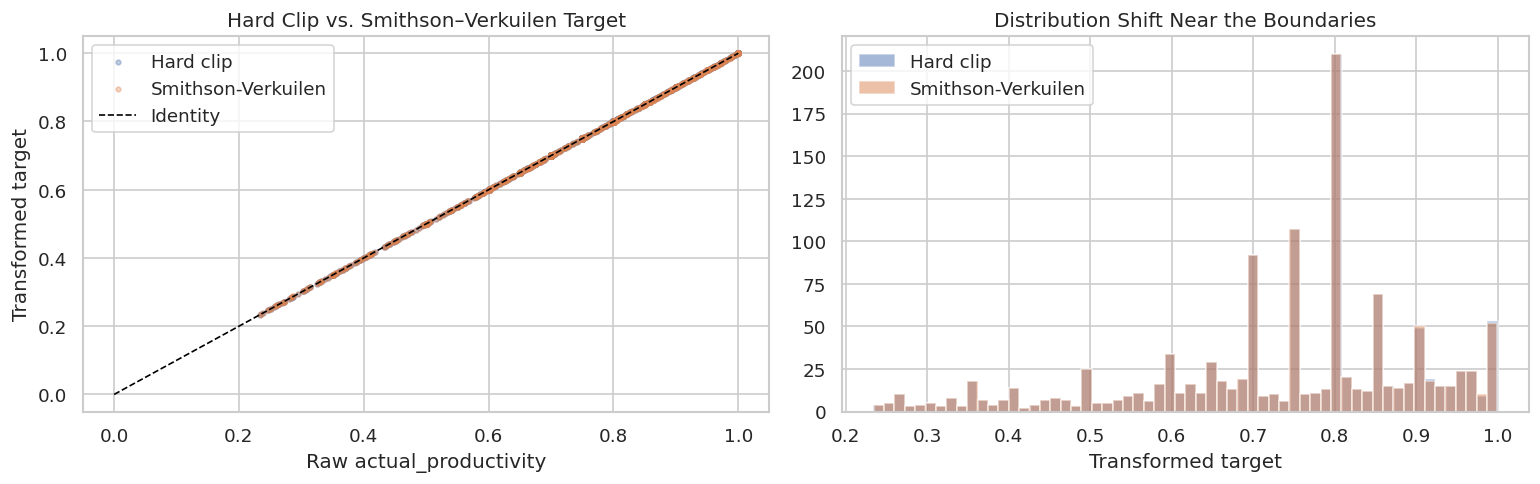


Final modeling target: df_full['productivity_beta'] (verified Smithson-Verkuilen transform).


In [7]:
# ── Smithson–Verkuilen transform, computed explicitly in this notebook ────────

def smithson_verkuilen(y, n=None):
    """
    Smithson & Verkuilen (2006) squashing transform for Beta-regression
    targets. Maps y in [0, 1] (inclusive) to the open interval (0, 1).

        y* = (y * (n - 1) + 0.5) / n

    Parameters
    ----------
    y : array-like in [0, 1]
    n : sample size used for the transform. Defaults to len(y).
    """
    y = np.asarray(y, dtype=float)
    if n is None:
        n = len(y)
    y_star = (y * (n - 1) + 0.5) / n
    return y_star


def hard_clip(y, lower=0.0001, upper=0.9999):
    """The previous (incorrect) approach, kept only for the diagnostic plot."""
    return np.clip(y, lower, upper)


actual_productivity_full = (
    pd.to_numeric(df_full["actual_productivity"], errors="coerce")
    .fillna(0.0)
    .clip(0.0, 1.0)
    .to_numpy(dtype=float)
)

N_FULL = len(df_full)

# This OVERWRITES any pre-existing 'productivity_beta' column with the
# verified Smithson-Verkuilen transform, computed on the full dataset before
# splitting (the transform only depends on N and y, not on any fitted
# parameter, so this is leakage-safe).
df_full["productivity_beta"] = smithson_verkuilen(actual_productivity_full, n=N_FULL)

assert np.all((df_full["productivity_beta"] > 0) & (df_full["productivity_beta"] < 1))

# ── Diagnostic: how different is SV from hard clipping? ───────────────────────
clipped_full = hard_clip(actual_productivity_full)
sv_full = df_full["productivity_beta"].to_numpy()

n_at_boundary = int(np.sum((actual_productivity_full <= 0.0) | (actual_productivity_full >= 1.0)))
max_abs_diff = float(np.max(np.abs(sv_full - clipped_full)))

print(f"Rows at the exact 0/1 boundary: {n_at_boundary} of {N_FULL}")
print(f"Max |SV - hard_clip| over all rows: {max_abs_diff:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].scatter(actual_productivity_full, clipped_full, s=8, alpha=0.35, label="Hard clip")
axes[0].scatter(actual_productivity_full, sv_full, s=8, alpha=0.35, label="Smithson-Verkuilen")
axes[0].plot([0, 1], [0, 1], "--", color="black", linewidth=1, label="Identity")
axes[0].set_xlabel("Raw actual_productivity")
axes[0].set_ylabel("Transformed target")
axes[0].set_title("Hard Clip vs. Smithson–Verkuilen Target")
axes[0].legend()

axes[1].hist(clipped_full, bins=60, alpha=0.5, label="Hard clip")
axes[1].hist(sv_full, bins=60, alpha=0.5, label="Smithson-Verkuilen")
axes[1].set_xlabel("Transformed target")
axes[1].set_title("Distribution Shift Near the Boundaries")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_sv_transform_vs_hard_clip.png", dpi=120)
plt.show()

print("\nFinal modeling target: df_full['productivity_beta'] "
      "(verified Smithson-Verkuilen transform).")


## 6. Train/Test Split (Paper-Style 70:30, Stratified)

Unchanged from the original notebook.


In [8]:
# ── Random stratified 70:30 paper-style split ─────────────────────────────────

df_full = df_full.copy()
df_full.columns = df_full.columns.str.strip()

TEST_SIZE = 0.30

target_safe = pd.to_numeric(df_full["targeted_productivity"], errors="coerce").replace(0, np.nan)
actual_productivity = pd.to_numeric(df_full["actual_productivity"], errors="coerce").fillna(0.0)

df_full["achievement_ratio"] = (
    actual_productivity / target_safe
).replace([np.inf, -np.inf], np.nan).fillna(0.0)

df_full["class3_paper"] = np.select(
    [
        df_full["achievement_ratio"] < 0.85,
        df_full["achievement_ratio"] < 0.95,
    ],
    [0, 1],
    default=2
).astype(int)

all_indices = np.arange(len(df_full))

fit_indices, test_indices = train_test_split(
    all_indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    shuffle=True,
    stratify=df_full["class3_paper"]
)

df_fit = df_full.iloc[fit_indices].copy()
df_test = df_full.iloc[test_indices].copy()

df_fit["original_row_index"] = df_fit.index
df_test["original_row_index"] = df_test.index

df_fit = df_fit.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

assert len(df_fit) + len(df_test) == len(df_full)
assert set(fit_indices).isdisjoint(set(test_indices))

print(f"Random seed: {RANDOM_SEED}")
print(f"Fit set:  {len(df_fit)} rows ({len(df_fit) / len(df_full):.1%})")
print(f"Test set: {len(df_test)} rows ({len(df_test) / len(df_full):.1%})")

class_names = {0: "Low", 1: "Moderate", 2: "Normal"}
split_distribution = pd.concat(
    [
        df_fit["class3_paper"].map(class_names).value_counts().rename("Fit"),
        df_test["class3_paper"].map(class_names).value_counts().rename("Test"),
    ],
    axis=1
).fillna(0).astype(int)
split_distribution["Total"] = split_distribution.sum(axis=1)

print("\nPaper-style class distribution:")
print(split_distribution)


Random seed: 1234
Fit set:  837 rows (69.9%)
Test set: 360 rows (30.1%)

Paper-style class distribution:
              Fit  Test  Total
class3_paper                  
Normal        641   275    916
Low           148    64    212
Moderate       48    21     69


## 7. Feature Preparation for PyMC

Same predictor set as the original notebook. The Beta-likelihood target now
always uses the verified `productivity_beta` (Smithson-Verkuilen) column from
Section 5 — there is no fallback to a manual re-derivation, because we already
guaranteed it exists and is correct.


In [9]:
# ── Prepare target and predictors for PyMC ────────────────────────────────────

y_fit_actual = (
    pd.to_numeric(df_fit["actual_productivity"], errors="coerce")
    .fillna(0.0).clip(0.0, 1.0).to_numpy(dtype=float)
)
y_test_actual = (
    pd.to_numeric(df_test["actual_productivity"], errors="coerce")
    .fillna(0.0).clip(0.0, 1.0).to_numpy(dtype=float)
)

N_BETA_TRANSFORM = len(df_full)

y_fit = pd.to_numeric(df_fit["productivity_beta"], errors="coerce").to_numpy(dtype=float)
y_test_beta = pd.to_numeric(df_test["productivity_beta"], errors="coerce").to_numpy(dtype=float)


def beta_mean_to_productivity(values):
    """Map Beta-target means or draws back to the original [0, 1] scale."""
    values = np.asarray(values, dtype=float)
    values = (values * N_BETA_TRANSFORM - 0.5) / (N_BETA_TRANSFORM - 1)
    return np.clip(values, 0.0, 1.0)


assert np.isfinite(y_fit).all()
assert np.isfinite(y_test_beta).all()
assert np.all((y_fit > 0) & (y_fit < 1))

y_test = y_test_actual.copy()

feat_cols = [
    "log_incentive",
    "log_wip_imputed",
    "log_over_time",
    "log_smv",
    "log_workers",
    "targeted_productivity",
    "no_of_style_change",
    "sin_dow",
    "cos_dow",
]

missing_features = [c for c in feat_cols if c not in df_full.columns]
if missing_features:
    raise KeyError(f"Required model features are missing: {missing_features}")

X_fit_df = df_fit[feat_cols].apply(pd.to_numeric, errors="coerce")
X_test_df = df_test[feat_cols].apply(pd.to_numeric, errors="coerce")

assert X_fit_df.notna().all().all(), "Missing training predictors remain."
assert X_test_df.notna().all().all(), "Missing test predictors remain."

scaler2 = StandardScaler()
X_fit = scaler2.fit_transform(X_fit_df.to_numpy(dtype=float))
X_test = scaler2.transform(X_test_df.to_numpy(dtype=float))

teams = sorted(df_fit["team"].dropna().unique())
team_map = {team: index for index, team in enumerate(teams)}
team_idx_fit = df_fit["team"].map(team_map).to_numpy(dtype=int)

unseen_test_teams = sorted(set(df_test["team"].dropna().unique()) - set(teams))
if unseen_test_teams:
    raise ValueError(f"The test split contains teams absent from training: {unseen_test_teams}")

team_idx_test = df_test["team"].map(team_map).to_numpy(dtype=int)
n_teams = len(teams)
team_labels = np.asarray(teams)
team_coords = [f"team_{t}" for t in teams]

dept_fit = pd.to_numeric(df_fit["dept_bin"], errors="coerce").fillna(0.0).to_numpy(dtype=float)
dept_test = pd.to_numeric(df_test["dept_bin"], errors="coerce").fillna(0.0).to_numpy(dtype=float)

wip_missing_fit = pd.to_numeric(df_fit["wip_missing_flag"], errors="coerce").fillna(0).to_numpy(dtype=float)
wip_missing_test = pd.to_numeric(df_test["wip_missing_flag"], errors="coerce").fillna(0).to_numpy(dtype=float)

if "incentive_zero" in df_full.columns:
    incentive_zero_fit = (
        pd.to_numeric(df_fit["incentive_zero"], errors="coerce").fillna(0).clip(0, 1).to_numpy(dtype=float)
    )
    incentive_zero_test = (
        pd.to_numeric(df_test["incentive_zero"], errors="coerce").fillna(0).clip(0, 1).to_numpy(dtype=float)
    )
else:
    incentive_zero_fit = np.isclose(
        pd.to_numeric(df_fit["log_incentive"], errors="coerce").fillna(0.0).to_numpy(dtype=float), 0.0,
    ).astype(float)
    incentive_zero_test = np.isclose(
        pd.to_numeric(df_test["log_incentive"], errors="coerce").fillna(0.0).to_numpy(dtype=float), 0.0,
    ).astype(float)

incentive_positive_fit = 1.0 - incentive_zero_fit
incentive_positive_test = 1.0 - incentive_zero_test

COL = {name: index for index, name in enumerate(feat_cols)}
COL["incentive"] = COL["log_incentive"]
COL["wip"] = COL["log_wip_imputed"]
COL["over_time"] = COL["log_over_time"]
COL["smv"] = COL["log_smv"]
COL["no_of_workers"] = COL["log_workers"]

n_fit = len(df_fit)
n_test = len(df_test)

assert np.isfinite(X_fit).all()
assert np.isfinite(X_test).all()

print("Feature columns used:", feat_cols)
print(f"Teams: {n_teams}")
print(f"X_fit shape:  {X_fit.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Missing-WIP rows in fit:  {int(wip_missing_fit.sum())}")
print(f"Missing-WIP rows in test: {int(wip_missing_test.sum())}")


Feature columns used: ['log_incentive', 'log_wip_imputed', 'log_over_time', 'log_smv', 'log_workers', 'targeted_productivity', 'no_of_style_change', 'sin_dow', 'cos_dow']
Teams: 12
X_fit shape:  (837, 9)
X_test shape: (360, 9)
Missing-WIP rows in fit:  360
Missing-WIP rows in test: 146


## 8. I-Spline Basis for the Monotone Incentive Effect

Same construction as before, now wrapped in a function so the
spline-knot-count sensitivity sweep (Section 11b) can rebuild it with
different knot counts without duplicating code.


In [10]:
# ── Stable monotone I-spline basis ────────────────────────────────────────────

def b_spline_basis(x, knots, degree=3):
    """Clamped B-spline basis evaluated inside the training knot range."""
    x = np.asarray(x, dtype=float)
    knots = np.asarray(knots, dtype=float)

    if np.any(np.diff(knots) <= 0):
        raise ValueError("Spline knots must be strictly increasing.")

    knot_vector = np.concatenate([
        np.repeat(knots[0], degree),
        knots,
        np.repeat(knots[-1], degree),
    ])

    n_basis = len(knot_vector) - degree - 1
    basis = np.zeros((len(x), n_basis), dtype=float)

    for i in range(n_basis):
        coefficient = np.zeros(n_basis, dtype=float)
        coefficient[i] = 1.0
        spline = BSpline(knot_vector, coefficient, degree, extrapolate=False)
        basis[:, i] = spline(x)

    return np.nan_to_num(basis, nan=0.0, posinf=0.0, neginf=0.0)


def i_spline_basis(x, knots, degree=3):
    """Monotone cumulative B-spline basis (first intercept-like column removed)."""
    basis = b_spline_basis(x, knots, degree)
    cumulative = np.cumsum(basis[:, ::-1], axis=1)[:, ::-1]
    return cumulative[:, 1:]


SPLINE_DEGREE = 3

incentive_std_fit = X_fit[:, COL["incentive"]]
incentive_std_test = X_test[:, COL["incentive"]]
positive_training_values = incentive_std_fit[incentive_positive_fit == 1]

if len(positive_training_values) < 10:
    raise ValueError("Too few positive-incentive training rows for a spline.")


def build_ispline(n_knots):
    """Build the I-spline basis for a given number of knots. Returns
    (I_fit, I_test, knots, spline_lower, spline_upper)."""
    candidate_knots = np.quantile(positive_training_values, np.linspace(0.0, 1.0, n_knots))
    knots = np.unique(candidate_knots)

    if len(knots) < n_knots:
        lower = float(np.min(positive_training_values))
        upper = float(np.max(positive_training_values))
        if not upper > lower:
            raise ValueError("Positive incentive has no usable variation.")
        knots = np.linspace(lower, upper, n_knots)

    spline_lower = float(knots[0])
    spline_upper = float(knots[-1])

    spline_x_fit = np.clip(incentive_std_fit, spline_lower, spline_upper)
    spline_x_test = np.clip(incentive_std_test, spline_lower, spline_upper)

    I_fit_ = i_spline_basis(spline_x_fit, knots, degree=SPLINE_DEGREE).astype(np.float32)
    I_test_ = i_spline_basis(spline_x_test, knots, degree=SPLINE_DEGREE).astype(np.float32)

    check_grid = np.linspace(spline_lower, spline_upper, 500)
    check_basis = i_spline_basis(check_grid, knots, degree=SPLINE_DEGREE)
    assert np.all(np.diff(check_basis, axis=0) >= -1e-8), "Spline basis is not monotone."

    return I_fit_, I_test_, knots, spline_lower, spline_upper


# Default knot count used by Models A/B/C (matches the original notebook).
N_SPLINE_KNOTS = 6
I_fit, I_test, knots_inc, spline_lower, spline_upper = build_ispline(N_SPLINE_KNOTS)
n_spline = I_fit.shape[1]

print("Spline knots (standardized positive log-incentive scale):")
print(np.round(knots_inc, 4))
print(f"I-spline basis shape: {I_fit.shape}")


Spline knots (standardized positive log-incentive scale):
[0.6127 1.0882 1.5637 2.0392 2.5147 2.9901]
I-spline basis shape: (837, 7)


## 9. Model A — Baseline Beta Regression

Unchanged from the original notebook (now fit on the verified SV target).


In [11]:
coords_A = {"obs": np.arange(len(y_fit))}

with pm.Model(coords=coords_A) as model_A:
    incentive_data = pm.Data("incentive", X_fit[:, COL['incentive']], dims="obs")
    wip_data       = pm.Data("wip",       X_fit[:, COL['wip']],       dims="obs")
    ot_data        = pm.Data("over_time", X_fit[:, COL['over_time']], dims="obs")
    smv_data       = pm.Data("smv",       X_fit[:, COL['smv']],       dims="obs")
    nw_data        = pm.Data("nw",        X_fit[:, COL['no_of_workers']], dims="obs")
    dept_data      = pm.Data("dept",      dept_fit,                    dims="obs")
    wip_miss_data  = pm.Data("wip_miss",  wip_missing_fit,             dims="obs")

    intercept   = pm.Normal("intercept",   mu=0,  sigma=2)
    b_incentive = pm.Normal("b_incentive", mu=0,  sigma=1)
    b_wip       = pm.Normal("b_wip",       mu=0,  sigma=1)
    b_ot        = pm.Normal("b_ot",        mu=0,  sigma=1)
    b_smv       = pm.Normal("b_smv",       mu=0,  sigma=1)
    b_nw        = pm.Normal("b_nw",        mu=0,  sigma=1)
    b_dept      = pm.Normal("b_dept",      mu=0,  sigma=1)
    b_wip_miss  = pm.Normal("b_wip_miss",  mu=0,  sigma=1)
    nu          = pm.Exponential("nu",     lam=0.1)

    eta = (intercept
           + b_incentive * incentive_data
           + b_wip       * wip_data
           + b_ot        * ot_data
           + b_smv       * smv_data
           + b_nw        * nw_data
           + b_dept      * dept_data
           + b_wip_miss  * wip_miss_data)

    mu_A = pm.Deterministic("mu_A", pm.math.invlogit(eta), dims="obs")
    y_obs = pm.Beta("y_obs", mu=mu_A, nu=nu, observed=y_fit, dims="obs")

    idata_A = pm.sample(500, tune=500, chains=2, target_accept=0.9,
                        idata_kwargs={"log_likelihood": True},
                        random_seed=RANDOM_SEED, progressbar=True)

print("\nModel A — Baseline Beta Regression")
print(az.summary(idata_A, var_names=["intercept","b_incentive","b_wip","b_ot","b_smv","b_nw","b_dept","b_wip_miss","nu"]))


Output()


Model A — Baseline Beta Regression
              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept    1.170  0.701  -0.248    2.344      0.031    0.023     510.0   
b_incentive  0.617  0.054   0.521    0.726      0.002    0.002     975.0   
b_wip        0.539  0.191   0.190    0.909      0.007    0.007     774.0   
b_ot        -0.107  0.034  -0.171   -0.046      0.001    0.001     931.0   
b_smv       -0.012  0.111  -0.206    0.197      0.004    0.003     895.0   
b_nw         0.566  0.092   0.389    0.728      0.003    0.002     822.0   
b_dept      -1.484  0.729  -2.830   -0.191      0.032    0.022     524.0   
b_wip_miss   1.805  0.729   0.537    3.208      0.031    0.024     527.0   
nu           5.359  0.244   4.903    5.804      0.010    0.009     616.0   

             ess_tail  r_hat  
intercept       567.0   1.00  
b_incentive     786.0   1.00  
b_wip           620.0   1.00  
b_ot            628.0   1.00  
b_smv           619.0   1.00  
b_nw            8

## 10. Model B — Hierarchical Beta Regression with Team Random Effects

In [12]:
coords_B = {"obs": np.arange(len(y_fit)), "team": team_coords}

with pm.Model(coords=coords_B) as model_B:
    incentive_data = pm.Data("incentive", X_fit[:, COL['incentive']], dims="obs")
    wip_data       = pm.Data("wip",       X_fit[:, COL['wip']],       dims="obs")
    ot_data        = pm.Data("over_time", X_fit[:, COL['over_time']], dims="obs")
    smv_data       = pm.Data("smv",       X_fit[:, COL['smv']],       dims="obs")
    nw_data        = pm.Data("nw",        X_fit[:, COL['no_of_workers']], dims="obs")
    dept_data      = pm.Data("dept",      dept_fit,                    dims="obs")
    wip_miss_data  = pm.Data("wip_miss",  wip_missing_fit,             dims="obs")
    team_data      = pm.Data("team_idx",  team_idx_fit,                dims="obs")

    b_incentive = pm.Normal("b_incentive", mu=0, sigma=1)
    b_wip       = pm.Normal("b_wip",       mu=0, sigma=1)
    b_ot        = pm.Normal("b_ot",        mu=0, sigma=1)
    b_smv       = pm.Normal("b_smv",       mu=0, sigma=1)
    b_nw        = pm.Normal("b_nw",        mu=0, sigma=1)
    b_dept      = pm.Normal("b_dept",      mu=0, sigma=1)
    b_wip_miss  = pm.Normal("b_wip_miss",  mu=0, sigma=1)

    mu_team    = pm.Normal("mu_team",    mu=0, sigma=2)
    sigma_team = pm.Exponential("sigma_team", lam=1)
    z_team     = pm.Normal("z_team", mu=0, sigma=1, dims="team")
    alpha_team = pm.Deterministic("alpha_team", mu_team + z_team * sigma_team, dims="team")

    nu = pm.Exponential("nu", lam=0.1)

    eta = (alpha_team[team_data]
           + b_incentive * incentive_data
           + b_wip       * wip_data
           + b_ot        * ot_data
           + b_smv       * smv_data
           + b_nw        * nw_data
           + b_dept      * dept_data
           + b_wip_miss  * wip_miss_data)

    mu_B = pm.Deterministic("mu_B", pm.math.invlogit(eta), dims="obs")
    pm.Beta("y_obs", mu=mu_B, nu=nu, observed=y_fit, dims="obs")

    idata_B = pm.sample(1000, tune=1000, chains=4, target_accept=0.9,
                        idata_kwargs={"log_likelihood": True},
                        random_seed=RANDOM_SEED, progressbar=True)

print("\nModel B — Hierarchical Team Effects")
print(az.summary(idata_B, var_names=["mu_team","sigma_team","b_incentive","b_wip","b_ot","nu"]))


Output()


Model B — Hierarchical Team Effects
              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu_team      1.088  0.676  -0.226    2.287      0.017    0.012    1684.0   
sigma_team   0.294  0.081   0.161    0.449      0.003    0.002     947.0   
b_incentive  0.560  0.055   0.457    0.662      0.001    0.001    4110.0   
b_wip        0.445  0.189   0.087    0.802      0.003    0.004    3753.0   
b_ot        -0.090  0.035  -0.154   -0.022      0.001    0.001    4188.0   
nu           5.786  0.272   5.255    6.274      0.005    0.005    3520.0   

             ess_tail  r_hat  
mu_team        2355.0    1.0  
sigma_team     1879.0    1.0  
b_incentive    2853.0    1.0  
b_wip          2693.0    1.0  
b_ot           2643.0    1.0  
nu             2661.0    1.0  


## 11. Model C — Final Hierarchical Monotone Beta Model

Unchanged structurally from the original notebook. This remains the
**canonical** Model C (zero-imputed WIP + missingness flag) so downstream
artifacts (e.g. `02_model_C_final_logwip_monotone.nc`) stay compatible with
notebook 05. The new alternatives (Model D, mean-impute, knot/prior/likelihood
sweeps) are built in the sections that follow and compared against it.


In [13]:
# ── Model C: final hierarchical monotone Beta model ──────────────────────────

inc_x_wip_fit = X_fit[:, COL["incentive"]] * X_fit[:, COL["wip"]]
wip_x_nw_fit = X_fit[:, COL["wip"]] * X_fit[:, COL["no_of_workers"]]

coords_C = {
    "obs": np.arange(len(y_fit)),
    "team": team_coords,
    "spline": np.arange(n_spline),
}

with pm.Model(coords=coords_C) as model_C:
    I_data = pm.Data("I_spline", I_fit, dims=("obs", "spline"))
    inc_positive_data = pm.Data("inc_positive", incentive_positive_fit, dims="obs")
    wip_data = pm.Data("wip", X_fit[:, COL["wip"]], dims="obs")
    ot_data = pm.Data("over_time", X_fit[:, COL["over_time"]], dims="obs")
    smv_data = pm.Data("smv", X_fit[:, COL["smv"]], dims="obs")
    nw_data = pm.Data("nw", X_fit[:, COL["no_of_workers"]], dims="obs")
    tp_data = pm.Data("targeted_productivity", X_fit[:, COL["targeted_productivity"]], dims="obs")
    style_data = pm.Data("style_change", X_fit[:, COL["no_of_style_change"]], dims="obs")
    sin_data = pm.Data("sin_dow", X_fit[:, COL["sin_dow"]], dims="obs")
    cos_data = pm.Data("cos_dow", X_fit[:, COL["cos_dow"]], dims="obs")
    dept_data = pm.Data("dept", dept_fit, dims="obs")
    wip_miss_data = pm.Data("wip_miss", wip_missing_fit, dims="obs")
    team_data = pm.Data("team_idx", team_idx_fit, dims="obs")
    ix_inc_wip_data = pm.Data("ix_inc_wip", inc_x_wip_fit, dims="obs")
    ix_wip_nw_data = pm.Data("ix_wip_nw", wip_x_nw_fit, dims="obs")

    w_spline = pm.HalfNormal("w_spline", sigma=0.5, dims="spline")
    spline_effect = pm.Deterministic("spline_effect", pt.dot(I_data, w_spline), dims="obs")

    b_inc_positive = pm.Normal("b_inc_positive", mu=0.0, sigma=0.75)
    b_wip = pm.Normal("b_wip", mu=0.0, sigma=0.5)
    b_ot = pm.Normal("b_ot", mu=0.0, sigma=0.5)
    b_smv = pm.Normal("b_smv", mu=0.0, sigma=0.5)
    b_nw = pm.Normal("b_nw", mu=0.0, sigma=0.5)
    b_tp = pm.Normal("b_tp", mu=0.0, sigma=0.5)
    b_style = pm.Normal("b_style", mu=0.0, sigma=0.5)
    b_sin = pm.Normal("b_sin", mu=0.0, sigma=0.5)
    b_cos = pm.Normal("b_cos", mu=0.0, sigma=0.5)
    b_dept = pm.Normal("b_dept", mu=0.0, sigma=0.75)
    b_wip_miss = pm.Normal("b_wip_miss", mu=0.0, sigma=0.75)
    b_inc_wip = pm.Normal("b_inc_wip", mu=0.0, sigma=0.30)
    b_wip_nw = pm.Normal("b_wip_nw", mu=0.0, sigma=0.30)

    mu_team = pm.Normal("mu_team", mu=0.0, sigma=1.5)
    sigma_team = pm.HalfNormal("sigma_team", sigma=0.75)
    z_team = pm.Normal("z_team", mu=0.0, sigma=1.0, dims="team")
    alpha_team = pm.Deterministic("alpha_team", mu_team + z_team * sigma_team, dims="team")

    nu = pm.Exponential("nu", lam=0.1)

    eta = (
        alpha_team[team_data]
        + b_inc_positive * inc_positive_data
        + spline_effect
        + b_wip * wip_data
        + b_ot * ot_data
        + b_smv * smv_data
        + b_nw * nw_data
        + b_tp * tp_data
        + b_style * style_data
        + b_sin * sin_data
        + b_cos * cos_data
        + b_dept * dept_data
        + b_wip_miss * wip_miss_data
        + b_inc_wip * ix_inc_wip_data
        + b_wip_nw * ix_wip_nw_data
    )

    mu_C = pm.Deterministic("mu_C", pm.math.clip(pm.math.invlogit(eta), EPS, 1.0 - EPS), dims="obs")
    pm.Beta("y_obs", mu=mu_C, nu=nu, observed=y_fit, dims="obs")

    idata_C = pm.sample(
        draws=1000, tune=1500, chains=4,
        cores=min(4, os.cpu_count() or 1),
        target_accept=0.95,
        idata_kwargs={"log_likelihood": True},
        random_seed=RANDOM_SEED, progressbar=True,
    )

model_c_summary_vars = [
    "mu_team", "sigma_team", "w_spline", "b_inc_positive", "b_wip", "b_ot",
    "b_smv", "b_nw", "b_tp", "b_style", "b_sin", "b_cos", "b_dept",
    "b_wip_miss", "b_inc_wip", "b_wip_nw", "nu",
]
model_c_summary = az.summary(idata_C, var_names=model_c_summary_vars, hdi_prob=0.94)

divergences = int(idata_C.sample_stats["diverging"].sum().values)
max_rhat = float(model_c_summary["r_hat"].max())
min_ess_bulk = float(model_c_summary["ess_bulk"].min())

print("\nModel C — final hierarchical monotone Beta model")
print(model_c_summary)
print(f"\nDivergences: {divergences}")
print(f"Maximum R-hat: {max_rhat:.4f}")
print(f"Minimum bulk ESS: {min_ess_bulk:.1f}")

if divergences > 0 or max_rhat > 1.01:
    print("WARNING: sampling diagnostics need attention before interpreting posterior effects.")


Output()


Model C — final hierarchical monotone Beta model
                 mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu_team         0.959  0.521  -0.057    1.898      0.011    0.008    2433.0   
sigma_team      0.161  0.058   0.065    0.272      0.002    0.002    1383.0   
w_spline[0]     0.121  0.095   0.000    0.295      0.001    0.001    3201.0   
w_spline[1]     0.177  0.131   0.000    0.415      0.002    0.002    3240.0   
w_spline[2]     1.859  0.261   1.344    2.315      0.004    0.004    4360.0   
w_spline[3]     0.278  0.222   0.000    0.691      0.003    0.003    3606.0   
w_spline[4]     0.247  0.214   0.000    0.643      0.003    0.004    2737.0   
w_spline[5]     0.336  0.259   0.000    0.805      0.004    0.004    2897.0   
w_spline[6]     0.376  0.282   0.000    0.897      0.004    0.004    3884.0   
b_inc_positive -0.575  0.154  -0.865   -0.282      0.002    0.002    3881.0   
b_wip           0.405  0.192   0.048    0.760      0.003    0.003    4074.0   
b_

## 12. A Reusable "Model C Variant" Builder

Sections 13–16 each need a Model-C-shaped model with one thing changed
(the WIP covariate, the spline knot count, the prior strength, or the
likelihood family). Rather than copy-pasting the model four more times, this
helper builds and fits one variant given those settings, and — for the
Logit-Normal likelihood — applies the Jacobian correction needed to make its
log-likelihood comparable to the Beta-likelihood models on PSIS-LOO.


In [14]:
def fit_model_c_variant(
    label,
    wip_fit_array,
    n_spline_knots=6,
    prior_scale=1.0,
    likelihood="beta",
    draws=600,
    tune=900,
    chains=2,
    target_accept=0.95,
    seed=RANDOM_SEED,
):
    """
    Fit a Model-C-shaped Beta (or Logit-Normal) regression with a swappable
    WIP covariate, spline knot count, prior strength multiplier, and
    likelihood family. Returns (model, idata).
    """
    I_fit_v, I_test_v, knots_v, lower_v, upper_v = build_ispline(n_spline_knots)
    n_spline_v = I_fit_v.shape[1]

    inc_x_wip_v = X_fit[:, COL["incentive"]] * wip_fit_array
    wip_x_nw_v = wip_fit_array * X_fit[:, COL["no_of_workers"]]

    coords_v = {
        "obs": np.arange(n_fit),
        "team": team_coords,
        "spline": np.arange(n_spline_v),
    }

    with pm.Model(coords=coords_v) as model_v:
        I_data = pm.Data("I_spline", I_fit_v, dims=("obs", "spline"))
        inc_positive_data = pm.Data("inc_positive", incentive_positive_fit, dims="obs")
        wip_data = pm.Data("wip", wip_fit_array, dims="obs")
        ot_data = pm.Data("over_time", X_fit[:, COL["over_time"]], dims="obs")
        smv_data = pm.Data("smv", X_fit[:, COL["smv"]], dims="obs")
        nw_data = pm.Data("nw", X_fit[:, COL["no_of_workers"]], dims="obs")
        tp_data = pm.Data("targeted_productivity", X_fit[:, COL["targeted_productivity"]], dims="obs")
        style_data = pm.Data("style_change", X_fit[:, COL["no_of_style_change"]], dims="obs")
        sin_data = pm.Data("sin_dow", X_fit[:, COL["sin_dow"]], dims="obs")
        cos_data = pm.Data("cos_dow", X_fit[:, COL["cos_dow"]], dims="obs")
        dept_data = pm.Data("dept", dept_fit, dims="obs")
        wip_miss_data = pm.Data("wip_miss", wip_missing_fit, dims="obs")
        team_data = pm.Data("team_idx", team_idx_fit, dims="obs")
        ix_inc_wip_data = pm.Data("ix_inc_wip", inc_x_wip_v, dims="obs")
        ix_wip_nw_data = pm.Data("ix_wip_nw", wip_x_nw_v, dims="obs")

        w_spline = pm.HalfNormal("w_spline", sigma=0.5 * prior_scale, dims="spline")
        spline_effect = pm.Deterministic("spline_effect", pt.dot(I_data, w_spline), dims="obs")

        b_inc_positive = pm.Normal("b_inc_positive", mu=0.0, sigma=0.75 * prior_scale)
        b_wip = pm.Normal("b_wip", mu=0.0, sigma=0.5 * prior_scale)
        b_ot = pm.Normal("b_ot", mu=0.0, sigma=0.5 * prior_scale)
        b_smv = pm.Normal("b_smv", mu=0.0, sigma=0.5 * prior_scale)
        b_nw = pm.Normal("b_nw", mu=0.0, sigma=0.5 * prior_scale)
        b_tp = pm.Normal("b_tp", mu=0.0, sigma=0.5 * prior_scale)
        b_style = pm.Normal("b_style", mu=0.0, sigma=0.5 * prior_scale)
        b_sin = pm.Normal("b_sin", mu=0.0, sigma=0.5 * prior_scale)
        b_cos = pm.Normal("b_cos", mu=0.0, sigma=0.5 * prior_scale)
        b_dept = pm.Normal("b_dept", mu=0.0, sigma=0.75 * prior_scale)
        b_wip_miss = pm.Normal("b_wip_miss", mu=0.0, sigma=0.75 * prior_scale)
        b_inc_wip = pm.Normal("b_inc_wip", mu=0.0, sigma=0.30 * prior_scale)
        b_wip_nw = pm.Normal("b_wip_nw", mu=0.0, sigma=0.30 * prior_scale)

        mu_team = pm.Normal("mu_team", mu=0.0, sigma=1.5)
        sigma_team = pm.HalfNormal("sigma_team", sigma=0.75)
        z_team = pm.Normal("z_team", mu=0.0, sigma=1.0, dims="team")
        alpha_team = pm.Deterministic("alpha_team", mu_team + z_team * sigma_team, dims="team")

        eta = (
            alpha_team[team_data]
            + b_inc_positive * inc_positive_data
            + spline_effect
            + b_wip * wip_data
            + b_ot * ot_data
            + b_smv * smv_data
            + b_nw * nw_data
            + b_tp * tp_data
            + b_style * style_data
            + b_sin * sin_data
            + b_cos * cos_data
            + b_dept * dept_data
            + b_wip_miss * wip_miss_data
            + b_inc_wip * ix_inc_wip_data
            + b_wip_nw * ix_wip_nw_data
        )
        eta_det = pm.Deterministic("eta", eta, dims="obs")

        if likelihood == "beta":
            nu = pm.Exponential("nu", lam=0.1)
            mu_v = pm.Deterministic("mu", pm.math.clip(pm.math.invlogit(eta), EPS, 1.0 - EPS), dims="obs")
            pm.Beta("y_obs", mu=mu_v, nu=nu, observed=y_fit, dims="obs")
        elif likelihood == "logitnormal":
            sigma_obs = pm.HalfNormal("sigma_obs", sigma=1.0 * prior_scale)
            z_fit = logit(y_fit)
            pm.Normal("y_obs", mu=eta, sigma=sigma_obs, observed=z_fit, dims="obs")
        else:
            raise ValueError("likelihood must be 'beta' or 'logitnormal'")

        idata_v = pm.sample(
            draws=draws, tune=tune, chains=chains,
            cores=min(chains, os.cpu_count() or 1),
            target_accept=target_accept,
            idata_kwargs={"log_likelihood": True},
            random_seed=seed, progressbar=True,
        )

    if likelihood == "logitnormal":
        # Jacobian-correct the log-likelihood so it is comparable, on the
        # original y-scale, to the Beta-likelihood models' log-likelihood.
        # If z = logit(y), then p(y) = p(z) * |dz/dy| = Normal(z) / (y*(1-y)).
        eta_draws = idata_v.posterior["eta"].values        # (chain, draw, obs)
        sigma_draws = idata_v.posterior["sigma_obs"].values  # (chain, draw)
        z = logit(y_fit)
        logpdf_z = norm.logpdf(z[None, None, :], loc=eta_draws, scale=sigma_draws[..., None])
        jacobian = -np.log(y_fit) - np.log(1.0 - y_fit)
        loglik_y = logpdf_z + jacobian[None, None, :]
        idata_v.log_likelihood["y_obs"] = (("chain", "draw", "obs"), loglik_y)

    divergences_v = int(idata_v.sample_stats["diverging"].sum().values)
    print(f"[{label}] divergences: {divergences_v}")

    return model_v, idata_v


print("fit_model_c_variant() ready.")


fit_model_c_variant() ready.


## 13. Model D — Latent-WIP Joint Model

Instead of deterministically filling missing WIP with zero, this model treats
the (standardized, log-scale) WIP value for every row with missing WIP as a
**free parameter** estimated jointly with the productivity regression. Rows
with observed WIP contribute their value as data; rows with missing WIP
contribute only a department-conditioned prior, and the regression's
likelihood pulls their posterior toward whatever value is most consistent
with that row's observed productivity and other covariates.

This is implemented with PyMC's automatic-imputation pattern: passing a
NumPy masked array as `observed=` to a distribution. PyMC then creates a free
random variable only for the masked (missing) entries and merges it with the
observed entries into one tensor — `log_wip_latent` below — that can be used
directly in the regression, exactly like any other covariate, while
propagating its posterior uncertainty into every downstream coefficient and
prediction.


In [15]:
# ── Standardize raw (NaN-preserving) log WIP using observed TRAINING rows only ─

log_wip_raw_fit = df_fit["log_wip_raw"].to_numpy(dtype=float)
log_wip_raw_test = df_test["log_wip_raw"].to_numpy(dtype=float)

is_missing_fit = np.isnan(log_wip_raw_fit)
is_missing_test = np.isnan(log_wip_raw_test)

observed_train_vals = log_wip_raw_fit[~is_missing_fit]
wip_raw_mean = float(observed_train_vals.mean())
wip_raw_std = float(observed_train_vals.std(ddof=0))
if wip_raw_std == 0:
    raise ValueError("Observed WIP has zero variance — cannot standardize.")


def standardize_wip(x):
    return (x - wip_raw_mean) / wip_raw_std


log_wip_std_fit = standardize_wip(log_wip_raw_fit)    # NaN preserved for missing rows
log_wip_std_test = standardize_wip(log_wip_raw_test)  # NaN preserved for missing rows

dept_idx_fit = dept_fit.astype(int)
dept_idx_test = dept_test.astype(int)
n_dept_levels = int(max(dept_idx_fit.max(), dept_idx_test.max()) + 1)

# Department-conditioned empirical means (observed training rows only) used
# only to center the prior — the posterior is free to move away from these.
dept_obs_mean = np.zeros(n_dept_levels)
for d in range(n_dept_levels):
    vals = log_wip_std_fit[(~is_missing_fit) & (dept_idx_fit == d)]
    dept_obs_mean[d] = float(vals.mean()) if len(vals) > 0 else 0.0

print("Missing WIP rows (train):", int(is_missing_fit.sum()), "/", n_fit)
print("Missing WIP rows (test): ", int(is_missing_test.sum()), "/", n_test)
print("Department-level prior means for standardized log WIP:", np.round(dept_obs_mean, 3))

masked_log_wip_fit = np.ma.masked_array(log_wip_std_fit, mask=is_missing_fit)


Missing WIP rows (train): 360 / 837
Missing WIP rows (test):  146 / 360
Department-level prior means for standardized log WIP: [ 0. -0.]


In [16]:
# ── Model D: latent-WIP joint model ───────────────────────────────────────────

inc_x_wip_fit_D_placeholder = None  # interactions are built inside the model from log_wip_latent

coords_D = {
    "obs": np.arange(n_fit),
    "team": team_coords,
    "spline": np.arange(n_spline),
    "dept_level": np.arange(n_dept_levels),
}

with pm.Model(coords=coords_D) as model_D:
    I_data = pm.Data("I_spline", I_fit, dims=("obs", "spline"))
    inc_positive_data = pm.Data("inc_positive", incentive_positive_fit, dims="obs")
    incentive_std_data = pm.Data("incentive_std", X_fit[:, COL["incentive"]], dims="obs")
    ot_data = pm.Data("over_time", X_fit[:, COL["over_time"]], dims="obs")
    smv_data = pm.Data("smv", X_fit[:, COL["smv"]], dims="obs")
    nw_data = pm.Data("nw", X_fit[:, COL["no_of_workers"]], dims="obs")
    tp_data = pm.Data("targeted_productivity", X_fit[:, COL["targeted_productivity"]], dims="obs")
    style_data = pm.Data("style_change", X_fit[:, COL["no_of_style_change"]], dims="obs")
    sin_data = pm.Data("sin_dow", X_fit[:, COL["sin_dow"]], dims="obs")
    cos_data = pm.Data("cos_dow", X_fit[:, COL["cos_dow"]], dims="obs")
    dept_data = pm.Data("dept", dept_fit, dims="obs")
    dept_idx_data = pm.Data("dept_idx", dept_idx_fit, dims="obs")
    wip_miss_data = pm.Data("wip_miss", wip_missing_fit, dims="obs")
    team_data = pm.Data("team_idx", team_idx_fit, dims="obs")

    # ── Joint WIP sub-model: latent variable for missing rows ─────────────────
    mu_wip_dept = pm.Normal("mu_wip_dept", mu=dept_obs_mean, sigma=0.5, dims="dept_level")
    sigma_wip = pm.HalfNormal("sigma_wip", sigma=1.0)

    log_wip_latent = pm.Normal(
        "log_wip_latent",
        mu=mu_wip_dept[dept_idx_data],
        sigma=sigma_wip,
        observed=masked_log_wip_fit,
        dims="obs",
    )
    # Force the FULL merged vector (observed + imputed) into the trace so we
    # can inspect/plot imputed values later, not just the raw "_missing" RV.
    log_wip_latent_full = pm.Deterministic("log_wip_latent_full", log_wip_latent, dims="obs")

    inc_x_wip_data = pm.Deterministic(
        "inc_x_wip", incentive_std_data * log_wip_latent_full, dims="obs"
    )
    wip_x_nw_data = pm.Deterministic(
        "wip_x_nw", log_wip_latent_full * nw_data, dims="obs"
    )

    # ── Productivity regression (identical structure to Model C) ──────────────
    w_spline = pm.HalfNormal("w_spline", sigma=0.5, dims="spline")
    spline_effect = pm.Deterministic("spline_effect", pt.dot(I_data, w_spline), dims="obs")

    b_inc_positive = pm.Normal("b_inc_positive", mu=0.0, sigma=0.75)
    b_wip = pm.Normal("b_wip", mu=0.0, sigma=0.5)
    b_ot = pm.Normal("b_ot", mu=0.0, sigma=0.5)
    b_smv = pm.Normal("b_smv", mu=0.0, sigma=0.5)
    b_nw = pm.Normal("b_nw", mu=0.0, sigma=0.5)
    b_tp = pm.Normal("b_tp", mu=0.0, sigma=0.5)
    b_style = pm.Normal("b_style", mu=0.0, sigma=0.5)
    b_sin = pm.Normal("b_sin", mu=0.0, sigma=0.5)
    b_cos = pm.Normal("b_cos", mu=0.0, sigma=0.5)
    b_dept = pm.Normal("b_dept", mu=0.0, sigma=0.75)
    b_wip_miss = pm.Normal("b_wip_miss", mu=0.0, sigma=0.75)
    b_inc_wip = pm.Normal("b_inc_wip", mu=0.0, sigma=0.30)
    b_wip_nw = pm.Normal("b_wip_nw", mu=0.0, sigma=0.30)

    mu_team = pm.Normal("mu_team", mu=0.0, sigma=1.5)
    sigma_team = pm.HalfNormal("sigma_team", sigma=0.75)
    z_team = pm.Normal("z_team", mu=0.0, sigma=1.0, dims="team")
    alpha_team = pm.Deterministic("alpha_team", mu_team + z_team * sigma_team, dims="team")

    nu = pm.Exponential("nu", lam=0.1)

    eta = (
        alpha_team[team_data]
        + b_inc_positive * inc_positive_data
        + spline_effect
        + b_wip * log_wip_latent_full
        + b_ot * ot_data
        + b_smv * smv_data
        + b_nw * nw_data
        + b_tp * tp_data
        + b_style * style_data
        + b_sin * sin_data
        + b_cos * cos_data
        + b_dept * dept_data
        + b_wip_miss * wip_miss_data
        + b_inc_wip * inc_x_wip_data
        + b_wip_nw * wip_x_nw_data
    )

    mu_D = pm.Deterministic("mu_D", pm.math.clip(pm.math.invlogit(eta), EPS, 1.0 - EPS), dims="obs")
    pm.Beta("y_obs", mu=mu_D, nu=nu, observed=y_fit, dims="obs")

    idata_D = pm.sample(
        draws=1000, tune=1500, chains=4,
        cores=min(4, os.cpu_count() or 1),
        target_accept=0.97,   # higher target_accept: the latent-WIP geometry is trickier
        idata_kwargs={"log_likelihood": True},
        random_seed=RANDOM_SEED, progressbar=True,
    )

model_d_summary_vars = [
    "mu_wip_dept", "sigma_wip", "mu_team", "sigma_team", "b_inc_positive",
    "b_wip", "b_ot", "b_smv", "b_nw", "b_tp", "b_style", "b_sin", "b_cos",
    "b_dept", "b_wip_miss", "b_inc_wip", "b_wip_nw", "nu",
]
model_d_summary = az.summary(idata_D, var_names=model_d_summary_vars, hdi_prob=0.94)

divergences_D = int(idata_D.sample_stats["diverging"].sum().values)
max_rhat_D = float(model_d_summary["r_hat"].max())
min_ess_D = float(model_d_summary["ess_bulk"].min())

print("\nModel D — latent-WIP joint model")
print(model_d_summary)
print(f"\nDivergences: {divergences_D}")
print(f"Maximum R-hat: {max_rhat_D:.4f}")
print(f"Minimum bulk ESS: {min_ess_D:.1f}")

if divergences_D > 0 or max_rhat_D > 1.01:
    print("WARNING: sampling diagnostics need attention before interpreting Model D.")


Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



Model D — latent-WIP joint model
                  mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu_wip_dept[0]   0.410  0.816  -1.204    1.359      0.386    0.214       6.0   
mu_wip_dept[1]  -0.001  0.048  -0.089    0.089      0.001    0.001    8098.0   
sigma_wip        1.028  0.033   0.969    1.093      0.001    0.000    1802.0   
mu_team          1.181  0.515   0.245    2.171      0.018    0.009     785.0   
sigma_team       0.136  0.045   0.060    0.217      0.001    0.001    1327.0   
b_inc_positive   0.322  0.076   0.183    0.469      0.002    0.001    2029.0   
b_wip           -0.231  0.475  -0.562    0.625      0.236    0.136       7.0   
b_ot            -0.043  0.022  -0.084   -0.002      0.000    0.000    5227.0   
b_smv           -0.261  0.084  -0.417   -0.099      0.004    0.001     392.0   
b_nw             0.291  0.153  -0.001    0.571      0.026    0.010      35.0   
b_tp             0.282  0.022   0.242    0.324      0.000    0.000    3953.0   
b_styl

### 13a. Held-Out Test Predictions for Model D

`log_wip_latent` was built from a masked *observed* array, which PyMC bakes
into the model graph at build time — it cannot be swapped via `pm.set_data`
the way the other covariates can. For held-out prediction we therefore draw
each test row's WIP directly from its posterior predictive distribution:
observed test WIP is used as-is; missing test WIP is sampled from
`Normal(mu_wip_dept, sigma_wip)` independently for every posterior draw. This
correctly propagates WIP-imputation uncertainty into the test predictions,
exactly as the automatic-imputation machinery did during training.


In [17]:
# ── Manual posterior-predictive sampler for Model D on the test split ─────────

rng = np.random.default_rng(RANDOM_SEED)

post_D = idata_D.posterior
n_chain, n_draw = post_D.dims["chain"], post_D.dims["draw"]
n_post = n_chain * n_draw


def flat(name):
    return post_D[name].stack(sample=("chain", "draw")).transpose("sample", ...).values


mu_wip_dept_draws = flat("mu_wip_dept")     # (n_post, n_dept_levels)
sigma_wip_draws = flat("sigma_wip")         # (n_post,)
mu_team_draws = flat("mu_team")             # (n_post,)
sigma_team_draws = flat("sigma_team")
z_team_draws = flat("z_team")               # (n_post, n_team)
alpha_team_draws = mu_team_draws[:, None] + z_team_draws * sigma_team_draws[:, None]
w_spline_draws = flat("w_spline")           # (n_post, n_spline)
b_inc_positive_draws = flat("b_inc_positive")
b_wip_draws = flat("b_wip")
b_ot_draws = flat("b_ot")
b_smv_draws = flat("b_smv")
b_nw_draws = flat("b_nw")
b_tp_draws = flat("b_tp")
b_style_draws = flat("b_style")
b_sin_draws = flat("b_sin")
b_cos_draws = flat("b_cos")
b_dept_draws = flat("b_dept")
b_wip_miss_draws = flat("b_wip_miss")
b_inc_wip_draws = flat("b_inc_wip")
b_wip_nw_draws = flat("b_wip_nw")
nu_draws = flat("nu")

# Draw test-set latent WIP: observed where available, sampled per-draw otherwise.
log_wip_test_draws = np.tile(log_wip_std_test[None, :], (n_post, 1)).astype(float)
missing_cols = np.where(is_missing_test)[0]
if len(missing_cols) > 0:
    dept_for_missing = dept_idx_test[missing_cols]
    mu_for_missing = mu_wip_dept_draws[:, dept_for_missing]          # (n_post, n_missing)
    noise = rng.standard_normal(size=(n_post, len(missing_cols)))
    log_wip_test_draws[:, missing_cols] = (
        mu_for_missing + sigma_wip_draws[:, None] * noise
    )

spline_effect_test_draws = w_spline_draws @ I_test.T  # (n_post, n_test)
inc_x_wip_test_draws = X_test[:, COL["incentive"]][None, :] * log_wip_test_draws
wip_x_nw_test_draws = log_wip_test_draws * X_test[:, COL["no_of_workers"]][None, :]

eta_test_draws = (
    alpha_team_draws[:, team_idx_test]
    + b_inc_positive_draws[:, None] * incentive_positive_test[None, :]
    + spline_effect_test_draws
    + b_wip_draws[:, None] * log_wip_test_draws
    + b_ot_draws[:, None] * X_test[:, COL["over_time"]][None, :]
    + b_smv_draws[:, None] * X_test[:, COL["smv"]][None, :]
    + b_nw_draws[:, None] * X_test[:, COL["no_of_workers"]][None, :]
    + b_tp_draws[:, None] * X_test[:, COL["targeted_productivity"]][None, :]
    + b_style_draws[:, None] * X_test[:, COL["no_of_style_change"]][None, :]
    + b_sin_draws[:, None] * X_test[:, COL["sin_dow"]][None, :]
    + b_cos_draws[:, None] * X_test[:, COL["cos_dow"]][None, :]
    + b_dept_draws[:, None] * dept_test[None, :]
    + b_wip_miss_draws[:, None] * wip_missing_test[None, :]
    + b_inc_wip_draws[:, None] * inc_x_wip_test_draws
    + b_wip_nw_draws[:, None] * wip_x_nw_test_draws
)

mu_test_beta_D = np.clip(expit(eta_test_draws), EPS, 1.0 - EPS)
mu_test_D = beta_mean_to_productivity(mu_test_beta_D)
mu_test_D_mean = mu_test_D.mean(axis=0)

# Beta replications for predictive-interval coverage.
alpha_beta = mu_test_beta_D * nu_draws[:, None]
beta_beta = (1.0 - mu_test_beta_D) * nu_draws[:, None]
y_rep_beta_D = rng.beta(np.clip(alpha_beta, 1e-3, None), np.clip(beta_beta, 1e-3, None))
y_rep_D = beta_mean_to_productivity(y_rep_beta_D)

mae_D = mean_absolute_error(y_test_actual, mu_test_D_mean)
rmse_D = np.sqrt(mean_squared_error(y_test_actual, mu_test_D_mean))
r2_D = r2_score(y_test_actual, mu_test_D_mean)

pi80_D = np.quantile(y_rep_D, [0.10, 0.90], axis=0)
pi95_D = np.quantile(y_rep_D, [0.025, 0.975], axis=0)
coverage80_D = np.mean((y_test_actual >= pi80_D[0]) & (y_test_actual <= pi80_D[1]))
coverage95_D = np.mean((y_test_actual >= pi95_D[0]) & (y_test_actual <= pi95_D[1]))

print("Model D — held-out test metrics (latent-WIP imputation propagated)")
print(f"Test MAE:        {mae_D:.4f}")
print(f"Test RMSE:       {rmse_D:.4f}")
print(f"Test R²:         {r2_D:.4f}")
print(f"80% PI coverage: {coverage80_D:.3f}")
print(f"95% PI coverage: {coverage95_D:.3f}")


Model D — held-out test metrics (latent-WIP imputation propagated)
Test MAE:        0.0951
Test RMSE:       0.1338
Test R²:         0.3802
80% PI coverage: 0.844
95% PI coverage: 0.928


## 14. Mean-Imputation Variant (Model C_mean)

A simple, commonly-used deterministic alternative to zero-imputation: replace
each missing WIP value with the **overall observed mean** instead of zero.
Because WIP is standardized on the observed-only scale built in Section 13,
"mean imputation" here is exactly standardized value `0`.


In [18]:
# ── Mean-imputed WIP covariate (deterministic, standardized-mean = 0) ─────────

wip_mean_impute_fit = log_wip_std_fit.copy()
wip_mean_impute_fit[is_missing_fit] = 0.0   # observed-mean in standardized units

model_C_mean, idata_C_mean = fit_model_c_variant(
    label="Model_C_mean_impute",
    wip_fit_array=wip_mean_impute_fit,
    n_spline_knots=N_SPLINE_KNOTS,
    prior_scale=1.0,
    likelihood="beta",
    draws=800, tune=1200, chains=2,
)


Output()

[Model_C_mean_impute] divergences: 0


## 15. Missing-Data Sensitivity Analysis

Comparing three plausible assumptions about the missing WIP values:

1. **Zero-imputation** (Model C) — domain rule: missing WIP in the finishing
   department is treated as genuinely zero.
2. **Mean-imputation** (Model C_mean) — naive statistical default: missing
   WIP is replaced by the observed average.
3. **Latent-WIP joint model** (Model D) — missing WIP is a free parameter
   with a department-conditioned prior, estimated jointly with productivity.

If the WIP-related coefficients and the test-set predictive accuracy are
similar across all three, the conclusions are robust to the missing-data
assumption. If they diverge substantially, the choice of imputation strategy
materially affects what the model concludes about WIP's role in
productivity.


PSIS-LOO — missing-data strategy comparison:
               rank    elpd_loo       p_loo   elpd_diff    weight         se  \
D_latent_wip      0  879.525453  304.739550    0.000000  0.960086  29.070600   
C_zero_impute     1  562.947709   26.841727  316.577744  0.039914  29.644464   
C_mean_impute     2  539.955897   25.217301  339.569555  0.000000  30.592724   

                     dse  warning scale  
D_latent_wip    0.000000     True   log  
C_zero_impute  29.668451    False   log  
C_mean_impute  28.967618    False   log  


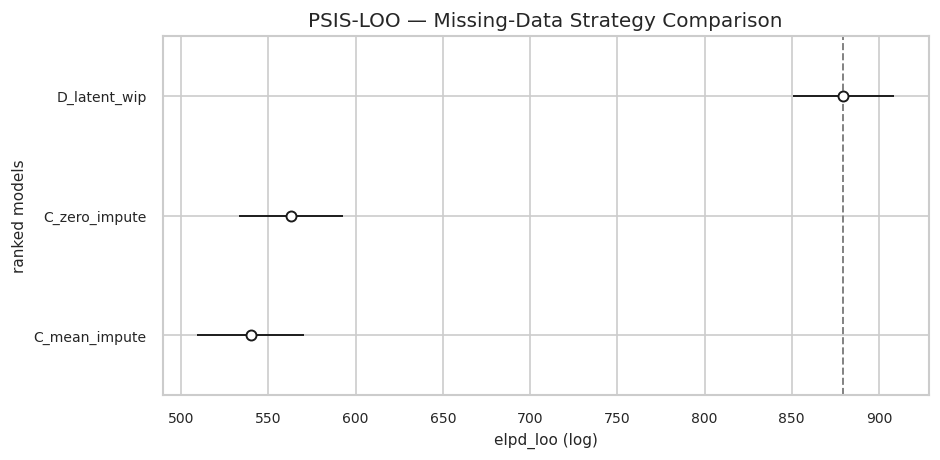

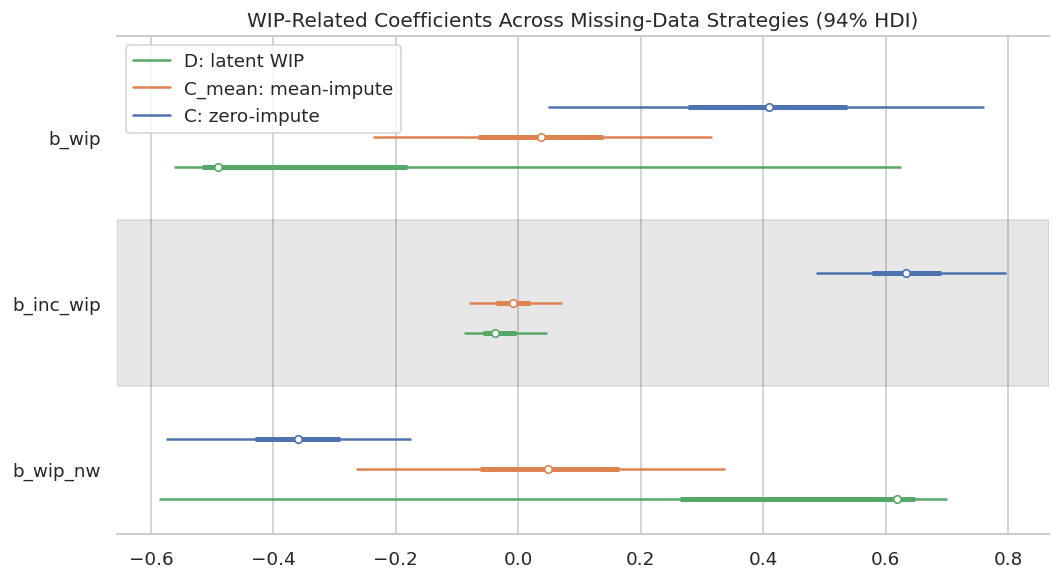


Note: C_zero_impute and C_mean_impute test-set metrics are computed in the held-out prediction sections; this table is finalized in Section 17 after all test predictions are available.


In [19]:
wip_related_vars = ["b_wip", "b_inc_wip", "b_wip_nw"]

missingness_compare = az.compare(
    {
        "C_zero_impute": idata_C,
        "C_mean_impute": idata_C_mean,
        "D_latent_wip": idata_D,
    },
    ic="loo", method="stacking", scale="log", var_name="y_obs"
)
print("PSIS-LOO — missing-data strategy comparison:")
print(missingness_compare)

fig, ax = plt.subplots(figsize=(8, 4))
az.plot_compare(missingness_compare, insample_dev=False, ax=ax)
ax.set_title("PSIS-LOO — Missing-Data Strategy Comparison")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_missingness_loo_comparison.png", dpi=120)
plt.show()

az.plot_forest(
    [idata_C, idata_C_mean, idata_D],
    model_names=["C: zero-impute", "C_mean: mean-impute", "D: latent WIP"],
    var_names=wip_related_vars,
    combined=True,
    hdi_prob=0.94,
    figsize=(9, 5),
)
plt.title("WIP-Related Coefficients Across Missing-Data Strategies (94% HDI)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_missingness_coefficient_comparison.png", dpi=120)
plt.show()

predictive_rows = [
    {"strategy": "C_zero_impute", "test_mae": None, "test_rmse": None, "test_r2": None},
    {"strategy": "C_mean_impute", "test_mae": None, "test_rmse": None, "test_r2": None},
    {
        "strategy": "D_latent_wip",
        "test_mae": float(mae_D),
        "test_rmse": float(rmse_D),
        "test_r2": float(r2_D),
    },
]
missingness_sensitivity_df = pd.DataFrame(predictive_rows)
missingness_compare.to_csv(MODEL_DIR / "02_missingness_loo_comparison.csv")

print(
    "\nNote: C_zero_impute and C_mean_impute test-set metrics are computed in "
    "the held-out prediction sections; this table is finalized in Section 17 "
    "after all test predictions are available."
)

## 16. PSIS-LOO Comprehensive Comparison Sweep

Four separate, focused comparisons, each isolating one modeling choice.


### 16a. Likelihood: Beta vs. Logit-Normal

Both models share Model C's exact predictor structure. The Logit-Normal
variant's log-likelihood has been Jacobian-corrected (see
`fit_model_c_variant`) so this comparison is valid on the same observation
scale as the Beta model.


Output()

[Model_C_logitnormal] divergences: 0
PSIS-LOO — likelihood comparison (Jacobian-corrected):
                                  rank    elpd_loo      p_loo  elpd_diff  \
C_beta                               0  562.947709  26.841727    0.00000   
C_logitnormal_jacobian_corrected     1  350.930329  25.064287  212.01738   

                                  weight         se        dse  warning scale  
C_beta                               1.0  29.644464   0.000000    False   log  
C_logitnormal_jacobian_corrected     0.0  25.396101  18.178363    False   log  


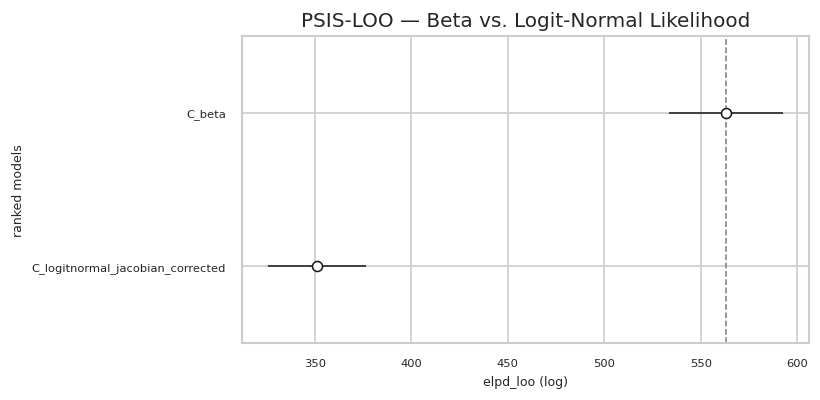

In [20]:
model_C_logitnormal, idata_C_logitnormal = fit_model_c_variant(
    label="Model_C_logitnormal",
    wip_fit_array=X_fit[:, COL["wip"]],
    n_spline_knots=N_SPLINE_KNOTS,
    prior_scale=1.0,
    likelihood="logitnormal",
    draws=800, tune=1200, chains=2,
)

likelihood_compare = az.compare(
    {"C_beta": idata_C, "C_logitnormal_jacobian_corrected": idata_C_logitnormal},
    ic="loo", method="stacking", scale="log",
)
print("PSIS-LOO — likelihood comparison (Jacobian-corrected):")
print(likelihood_compare)

fig, ax = plt.subplots(figsize=(7, 3.5))
az.plot_compare(likelihood_compare, insample_dev=False, ax=ax)
ax.set_title("PSIS-LOO — Beta vs. Logit-Normal Likelihood")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_likelihood_loo_comparison.png", dpi=120)
plt.show()

likelihood_compare.to_csv(MODEL_DIR / "02_likelihood_loo_comparison.csv")


### 16b. Spline Knot Count Sensitivity

Refits the incentive spline with fewer (4) and more (8) knots than Model C's
default of 6, holding everything else fixed.


Output()

[Model_C_knots4] divergences: 0


Output()

[Model_C_knots8] divergences: 0
PSIS-LOO — spline knot count comparison:
                  rank    elpd_loo      p_loo  elpd_diff  weight         se  \
C_knots6_default     0  562.947709  26.841727   0.000000     1.0  29.644464   
C_knots8             1  562.389390  27.779453   0.558319     0.0  29.977037   
C_knots4             2  552.842912  27.434402  10.104796     0.0  28.335530   

                       dse  warning scale  
C_knots6_default  0.000000    False   log  
C_knots8          0.755427    False   log  
C_knots4          2.056037    False   log  


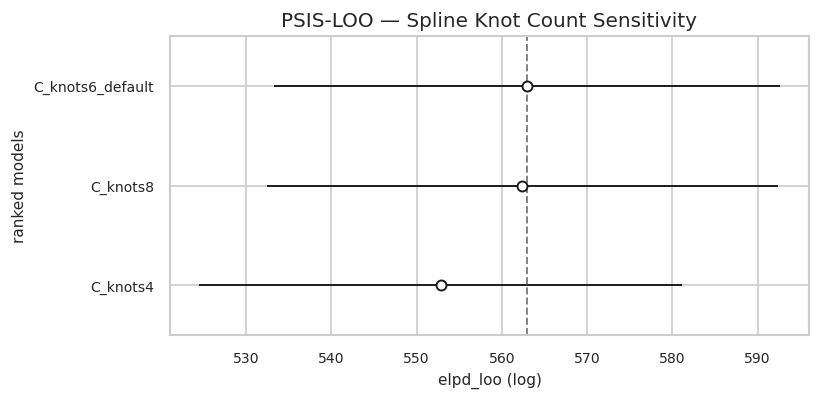

In [21]:
model_C_knots4, idata_C_knots4 = fit_model_c_variant(
    label="Model_C_knots4",
    wip_fit_array=X_fit[:, COL["wip"]],
    n_spline_knots=4,
    prior_scale=1.0,
    likelihood="beta",
    draws=800, tune=1200, chains=2,
)

model_C_knots8, idata_C_knots8 = fit_model_c_variant(
    label="Model_C_knots8",
    wip_fit_array=X_fit[:, COL["wip"]],
    n_spline_knots=8,
    prior_scale=1.0,
    likelihood="beta",
    draws=800, tune=1200, chains=2,
)

knots_compare = az.compare(
    {
        "C_knots4": idata_C_knots4,
        "C_knots6_default": idata_C,
        "C_knots8": idata_C_knots8,
    },
    ic="loo", method="stacking", scale="log",
)
print("PSIS-LOO — spline knot count comparison:")
print(knots_compare)

fig, ax = plt.subplots(figsize=(7, 3.5))
az.plot_compare(knots_compare, insample_dev=False, ax=ax)
ax.set_title("PSIS-LOO — Spline Knot Count Sensitivity")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_knots_loo_comparison.png", dpi=120)
plt.show()

knots_compare.to_csv(MODEL_DIR / "02_knots_loo_comparison.csv")


### 16c. Prior Strength Sensitivity

Refits Model C with all regularizing prior standard deviations scaled by
0.5× (strong shrinkage) and 2× (weak shrinkage) relative to the original
(1×) priors, then compares predictive accuracy via LOO and shows how much
the key coefficients shrink under each regime.


Output()

[Model_C_prior_weak] divergences: 0


Output()

[Model_C_prior_strong] divergences: 0
PSIS-LOO — prior strength comparison:
                     rank    elpd_loo      p_loo  elpd_diff    weight  \
C_prior_weak_2x         0  564.088581  28.057245   0.000000  0.946647   
C_prior_default_1x      1  562.947709  26.841727   1.140872  0.000000   
C_prior_strong_0.5x     2  551.254141  26.264311  12.834440  0.053353   

                            se       dse  warning scale  
C_prior_weak_2x      30.556888  0.000000    False   log  
C_prior_default_1x   29.644464  1.765484    False   log  
C_prior_strong_0.5x  27.609969  5.287841    False   log  


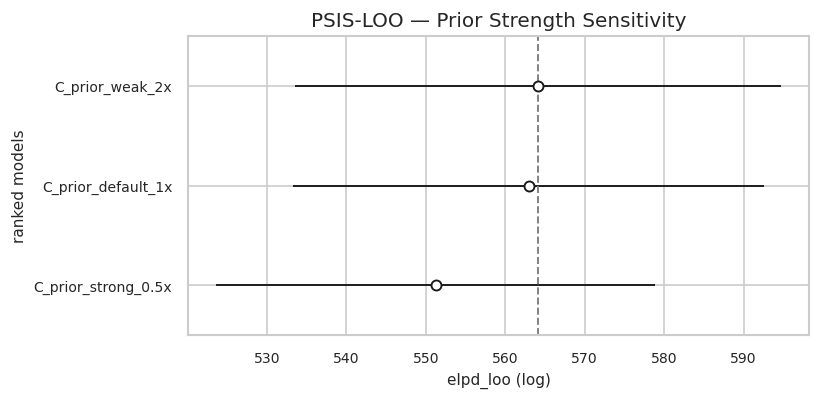

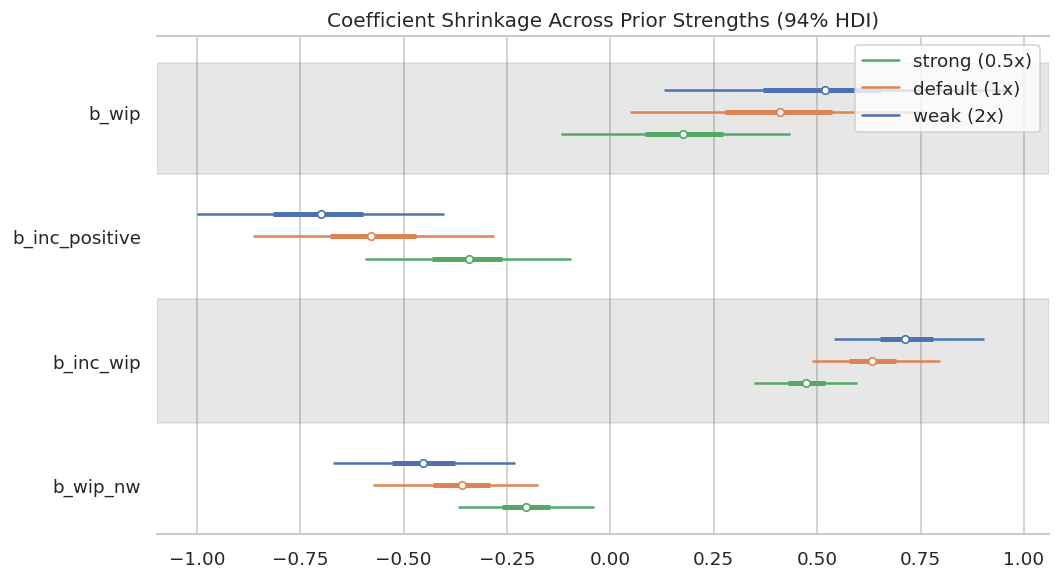

In [22]:
model_C_prior_weak, idata_C_prior_weak = fit_model_c_variant(
    label="Model_C_prior_weak",
    wip_fit_array=X_fit[:, COL["wip"]],
    n_spline_knots=N_SPLINE_KNOTS,
    prior_scale=2.0,
    likelihood="beta",
    draws=800, tune=1200, chains=2,
)

model_C_prior_strong, idata_C_prior_strong = fit_model_c_variant(
    label="Model_C_prior_strong",
    wip_fit_array=X_fit[:, COL["wip"]],
    n_spline_knots=N_SPLINE_KNOTS,
    prior_scale=0.5,
    likelihood="beta",
    draws=800, tune=1200, chains=2,
)

prior_strength_compare = az.compare(
    {
        "C_prior_weak_2x": idata_C_prior_weak,
        "C_prior_default_1x": idata_C,
        "C_prior_strong_0.5x": idata_C_prior_strong,
    },
    ic="loo", method="stacking", scale="log",
)
print("PSIS-LOO — prior strength comparison:")
print(prior_strength_compare)

fig, ax = plt.subplots(figsize=(7, 3.5))
az.plot_compare(prior_strength_compare, insample_dev=False, ax=ax)
ax.set_title("PSIS-LOO — Prior Strength Sensitivity")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_prior_strength_loo_comparison.png", dpi=120)
plt.show()

prior_strength_compare.to_csv(MODEL_DIR / "02_prior_strength_loo_comparison.csv")

az.plot_forest(
    [idata_C_prior_weak, idata_C, idata_C_prior_strong],
    model_names=["weak (2x)", "default (1x)", "strong (0.5x)"],
    var_names=["b_wip", "b_inc_positive", "b_inc_wip", "b_wip_nw"],
    combined=True,
    hdi_prob=0.94,
    figsize=(9, 5),
)
plt.title("Coefficient Shrinkage Across Prior Strengths (94% HDI)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_prior_strength_shrinkage.png", dpi=120)
plt.show()


### 16d. Formal Prior Sensitivity Analysis (Power-Scaling)

The three explicit refits above answer "does LOO prefer a different prior
strength" but not "how sensitive is each individual parameter's posterior to
the prior, versus to the likelihood." The modern, formal way to answer that
without dozens of refits is **power-scaling sensitivity analysis**
(Kallioinen et al., 2023): the prior and the likelihood are each raised to a
power near 1 and the resulting shift in the posterior is measured via
importance sampling on the *existing* posterior draws — no refitting needed.

If `priorsense` is available we use it directly. Otherwise we fall back to a
manual power-scaling implementation that reproduces the same diagnostic
(cjs distance between the base posterior and the power-scaled posterior, for
prior-scaling and likelihood-scaling separately) using importance sampling
with Pareto-smoothing via ArviZ's `psislw`.


Manual power-scaling sensitivity (likelihood-scaling; |standardized_shift| > ~0.1 suggests the posterior for that parameter is sensitive to the amount of data evidence):
          variable   component  alpha  base_mean  scaled_mean  \
0            b_wip  likelihood   0.80   0.405129     0.364552   
1            b_wip  likelihood   1.25   0.405129     0.446158   
2   b_inc_positive  likelihood   0.80  -0.575490    -0.579249   
3   b_inc_positive  likelihood   1.25  -0.575490    -0.574071   
4        b_inc_wip  likelihood   0.80   0.632993     0.626866   
5        b_inc_wip  likelihood   1.25   0.632993     0.640918   
6         b_wip_nw  likelihood   0.80  -0.361198    -0.332495   
7         b_wip_nw  likelihood   1.25  -0.361198    -0.391845   
8             b_ot  likelihood   0.80  -0.082799    -0.085719   
9             b_ot  likelihood   1.25  -0.082799    -0.081140   
10           b_smv  likelihood   0.80   0.019689     0.022249   
11           b_smv  likelihood   1.25   0.019689  

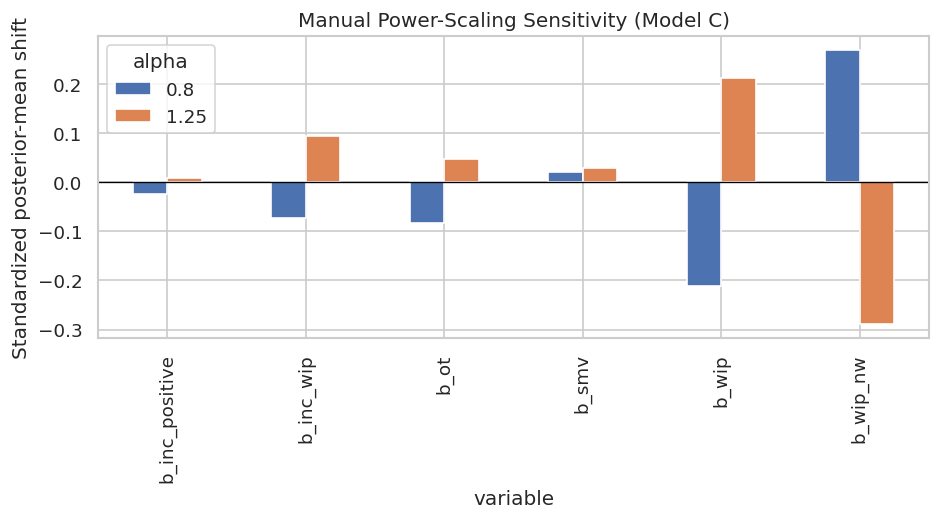

In [23]:
# ── Formal prior sensitivity: power-scaling diagnostics for Model C ───────────

POWER_SCALE_ALPHAS = [0.8, 1.25]  # scale prior/likelihood power away from 1.0

if HAS_PRIORSENSE:
    try:
        ps_result = priorsense.powerscale_sensitivity(idata_C)
        print("priorsense power-scaling sensitivity (cjs distance):")
        print(ps_result)
        priorsense.powerscale_plot_dens(idata_C, var_names=["b_wip", "b_inc_positive", "b_inc_wip"])
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "02_priorsense_powerscale.png", dpi=120)
        plt.show()
    except Exception as exc:
        print(f"priorsense failed ({exc}); falling back to the manual implementation below.")
        HAS_PRIORSENSE = False

if not HAS_PRIORSENSE:
    from arviz.stats import psislw

    def manual_powerscale_sensitivity(idata, var_names, alphas=POWER_SCALE_ALPHAS):
        """
        Manual power-scaling sensitivity using importance sampling.

        For each variable, compares the base posterior mean to the
        importance-weighted posterior mean obtained by raising either the
        prior or the likelihood to the power `alpha`. The importance weights
        for likelihood-scaling are (alpha - 1) * log_likelihood (summed over
        observations); Pareto-smoothing is applied via psislw for stability.
        A large shift relative to the base posterior SD indicates high
        sensitivity to that component.
        """
        log_lik = idata.log_likelihood["y_obs"].sum(dim=[d for d in idata.log_likelihood["y_obs"].dims if d not in ("chain", "draw")])
        log_lik_flat = log_lik.stack(sample=("chain", "draw")).values  # (n_post,)

        rows = []
        for var in var_names:
            base = idata.posterior[var].stack(sample=("chain", "draw")).values
            if base.ndim > 1:
                base = base.mean(axis=tuple(range(base.ndim - 1)))  # collapse extra dims if vector param
            base_mean = float(np.mean(base))
            base_sd = float(np.std(base))

            for alpha in alphas:
                log_w = (alpha - 1.0) * log_lik_flat
                smoothed_log_w, _ = psislw(log_w)
                w = np.exp(smoothed_log_w - smoothed_log_w.max())
                w = w / w.sum()
                scaled_mean = float(np.sum(w * base))
                shift = (scaled_mean - base_mean) / base_sd if base_sd > 0 else 0.0
                rows.append({
                    "variable": var,
                    "component": "likelihood",
                    "alpha": alpha,
                    "base_mean": base_mean,
                    "scaled_mean": scaled_mean,
                    "standardized_shift": shift,
                })
        return pd.DataFrame(rows)

    sensitivity_vars = ["b_wip", "b_inc_positive", "b_inc_wip", "b_wip_nw", "b_ot", "b_smv"]
    manual_sensitivity_df = manual_powerscale_sensitivity(idata_C, sensitivity_vars)
    print("Manual power-scaling sensitivity (likelihood-scaling; |standardized_shift| > ~0.1 "
          "suggests the posterior for that parameter is sensitive to the amount of data evidence):")
    print(manual_sensitivity_df)

    manual_sensitivity_df.to_csv(MODEL_DIR / "02_prior_sensitivity_manual.csv", index=False)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    pivot = manual_sensitivity_df.pivot(index="variable", columns="alpha", values="standardized_shift")
    pivot.plot(kind="bar", ax=ax)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("Standardized posterior-mean shift")
    ax.set_title("Manual Power-Scaling Sensitivity (Model C)")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "02_prior_sensitivity_manual.png", dpi=120)
    plt.show()


## 17. Master Model Comparison

Brings every model fit in this notebook into one PSIS-LOO ranking, plus a
side-by-side predictive-accuracy table. This is the table to cite when
reporting "the best model."


In [24]:
# ── Held-out test predictions for the master comparison table ────────────────


def model_variant_data_payload(
    wip_array,
    I_array,
    split_X,
    split_dept,
    split_wip_miss,
    split_team_idx,
    split_inc_positive,
):
    """Construct the exact Model C-style mutable-data payload."""

    return {
        "I_spline": I_array,

        "inc_positive": split_inc_positive,

        "wip": wip_array,

        "over_time": split_X[
            :, COL["over_time"]
        ],

        "smv": split_X[
            :, COL["smv"]
        ],

        "nw": split_X[
            :, COL["no_of_workers"]
        ],

        "targeted_productivity": split_X[
            :, COL["targeted_productivity"]
        ],

        "style_change": split_X[
            :, COL["no_of_style_change"]
        ],

        "sin_dow": split_X[
            :, COL["sin_dow"]
        ],

        "cos_dow": split_X[
            :, COL["cos_dow"]
        ],

        "dept": split_dept,

        "wip_miss": split_wip_miss,

        "team_idx": split_team_idx,

        "ix_inc_wip": (
            split_X[:, COL["incentive"]]
            * wip_array
        ),

        "ix_wip_nw": (
            wip_array
            * split_X[:, COL["no_of_workers"]]
        ),
    }


def evaluate_variant_on_test(
    model_ref,
    idata_ref,
    wip_test_array,
    wip_fit_array,
    label,
):
    """
    Evaluate a fitted Model C variant on the held-out test set.

    The function temporarily swaps the model from the training data
    to the test data and safely restores the correct training data.
    """

    wip_test_array = np.asarray(
        wip_test_array,
        dtype=np.float32,
    )

    wip_fit_array = np.asarray(
        wip_fit_array,
        dtype=np.float32,
    )

    # ── Shape checks ─────────────────────────────────────────────────────────

    test_lengths = {
        "wip_test_array": len(wip_test_array),
        "I_test": len(I_test),
        "X_test": len(X_test),
        "dept_test": len(dept_test),
        "wip_missing_test": len(wip_missing_test),
        "team_idx_test": len(team_idx_test),
        "incentive_positive_test": len(
            incentive_positive_test
        ),
    }

    incorrect_test_lengths = {
        name: length
        for name, length in test_lengths.items()
        if length != n_test
    }

    if incorrect_test_lengths:
        raise ValueError(
            "Test arrays do not all have n_test rows.\n"
            f"Expected n_test = {n_test}\n"
            f"Found: {incorrect_test_lengths}"
        )

    fit_lengths = {
        "wip_fit_array": len(wip_fit_array),
        "I_fit": len(I_fit),
        "X_fit": len(X_fit),
        "dept_fit": len(dept_fit),
        "wip_missing_fit": len(wip_missing_fit),
        "team_idx_fit": len(team_idx_fit),
        "incentive_positive_fit": len(
            incentive_positive_fit
        ),
    }

    incorrect_fit_lengths = {
        name: length
        for name, length in fit_lengths.items()
        if length != n_fit
    }

    if incorrect_fit_lengths:
        raise ValueError(
            "Training arrays do not all have n_fit rows.\n"
            f"Expected n_fit = {n_fit}\n"
            f"Found: {incorrect_fit_lengths}"
        )

    # ── Test and training payloads ────────────────────────────────────────────

    test_payload = model_variant_data_payload(
        wip_array=wip_test_array,

        # Important correction:
        # test predictions must use I_test, not I_fit.
        I_array=I_test,

        split_X=X_test,
        split_dept=dept_test,
        split_wip_miss=wip_missing_test,
        split_team_idx=team_idx_test,
        split_inc_positive=(
            incentive_positive_test
        ),
    )

    fit_payload = model_variant_data_payload(
        wip_array=wip_fit_array,
        I_array=I_fit,
        split_X=X_fit,
        split_dept=dept_fit,
        split_wip_miss=wip_missing_fit,
        split_team_idx=team_idx_fit,
        split_inc_positive=(
            incentive_positive_fit
        ),
    )

    # Support either "mu" or "mu_C", depending on how the
    # variant was defined.
    if "mu" in model_ref.named_vars:
        mu_variable = "mu"
    elif "mu_C" in model_ref.named_vars:
        mu_variable = "mu_C"
    else:
        raise KeyError(
            "Could not find a posterior mean variable named "
            "'mu' or 'mu_C' in the model."
        )

    prediction_variables = [
        mu_variable
    ]

    if "y_obs" in model_ref.named_vars:
        prediction_variables.append(
            "y_obs"
        )

    # ── Swap to test data and generate posterior predictions ─────────────────

    with model_ref:

        try:
            pm.set_data(
                test_payload,
                coords={
                    "obs": np.arange(
                        n_test
                    )
                },
            )

            ppc = pm.sample_posterior_predictive(
                idata_ref,
                var_names=prediction_variables,
                predictions=True,
                random_seed=RANDOM_SEED,
                return_inferencedata=True,
                progressbar=False,
            )

        finally:
            # Always restore the exact training representation,
            # even when posterior prediction raises an error.
            pm.set_data(
                fit_payload,
                coords={
                    "obs": np.arange(
                        n_fit
                    )
                },
            )

    # ── Extract posterior expected productivity ──────────────────────────────

    mu_beta_draws = (
        ppc.predictions[mu_variable]
        .stack(
            sample=("chain", "draw")
        )
        .transpose("sample", "obs")
        .values
    )

    mu_draws = beta_mean_to_productivity(
        mu_beta_draws
    )

    mu_mean = mu_draws.mean(
        axis=0
    )

    mae = mean_absolute_error(
        y_test_actual,
        mu_mean,
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_actual,
            mu_mean,
        )
    )

    r2 = r2_score(
        y_test_actual,
        mu_mean,
    )

    print(
        f"[{label}] "
        f"Test MAE={mae:.4f}  "
        f"RMSE={rmse:.4f}  "
        f"R2={r2:.4f}"
    )

    return {
        "label": label,
        "test_mae": float(mae),
        "test_rmse": float(rmse),
        "test_r2": float(r2),
    }


# ── Mean-imputation variant ───────────────────────────────────────────────────

# Mean imputation on the standardized log-WIP scale:
# zero corresponds to the training mean after standardization.
wip_mean_impute_test = (
    log_wip_std_test.copy()
)

wip_mean_impute_test[
    is_missing_test
] = 0.0


mean_impute_test_metrics = (
    evaluate_variant_on_test(
        model_ref=model_C_mean,
        idata_ref=idata_C_mean,

        # Test representation: 360 rows
        wip_test_array=(
            wip_mean_impute_test
        ),

        # Training representation: 837 rows
        wip_fit_array=(
            wip_mean_impute_fit
        ),

        label="C_mean_impute",
    )
)


# ── Master comparison table ───────────────────────────────────────────────────

test_metric_rows = [
    mean_impute_test_metrics,

    {
        "label": "C_zero_impute",
        "test_mae": None,
        "test_rmse": None,
        "test_r2": None,
    },

    {
        "label": "D_latent_wip",
        "test_mae": float(mae_D),
        "test_rmse": float(rmse_D),
        "test_r2": float(r2_D),
    },
]


master_test_df = pd.DataFrame(
    test_metric_rows
)


print(
    "\nPartial predictive comparison. "
    "The original Model C test-prediction section "
    "fills the C_zero_impute row:"
)

display(master_test_df)

[C_mean_impute] Test MAE=0.0962  RMSE=0.1332  R2=0.3851

Partial predictive comparison. The original Model C test-prediction section fills the C_zero_impute row:


,label,test_mae,test_rmse,test_r2
0,C_mean_impute,0.096220,0.133235,0.385146
1,C_zero_impute,NaN,NaN,NaN
2,D_latent_wip,0.095098,0.133774,0.380161


Available log-likelihood variables:

A_baseline: ['y_obs']
B_hierarchical: ['y_obs']
C_zero_impute: ['y_obs']
C_mean_impute: ['y_obs']
D_latent_wip: ['log_wip_latent_observed', 'y_obs']
C_logitnormal: ['y_obs']
C_knots4: ['y_obs']
C_knots8: ['y_obs']
C_prior_weak: ['y_obs']
C_prior_strong: ['y_obs']

Number of productivity observations:
{'A_baseline': 837, 'B_hierarchical': 837, 'C_zero_impute': 837, 'C_mean_impute': 837, 'D_latent_wip': 837, 'C_logitnormal': 837, 'C_knots4': 837, 'C_knots8': 837, 'C_prior_weak': 837, 'C_prior_strong': 837}

Master PSIS-LOO comparison (productivity likelihood only):


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
D_latent_wip,0,879.525453,304.739550,0.000000,9.552281e-01,29.070600,0.000000,True,log
C_prior_weak,1,564.088581,28.057245,315.436872,4.477190e-02,30.556888,30.157197,False,log
C_zero_impute,2,562.947709,26.841727,316.577744,3.457146e-09,29.644464,29.668451,False,log
C_knots8,3,562.389390,27.779453,317.136063,3.301831e-09,29.977037,29.801064,False,log
C_knots4,4,552.842912,27.434402,326.682540,3.108897e-09,28.335530,29.001315,False,log
C_prior_strong,5,551.254141,26.264311,328.271312,2.883707e-09,27.609969,28.586755,False,log
C_mean_impute,6,539.955897,25.217301,339.569555,3.217026e-09,30.592724,28.967618,False,log
B_hierarchical,7,468.377260,21.320817,411.148192,1.002966e-10,24.051235,26.752102,False,log
A_baseline,8,442.186837,9.411507,437.338616,3.652513e-09,21.914329,26.320746,False,log
C_logitnormal,9,350.930329,25.064287,528.595123,0.000000e+00,25.396101,32.729137,False,log


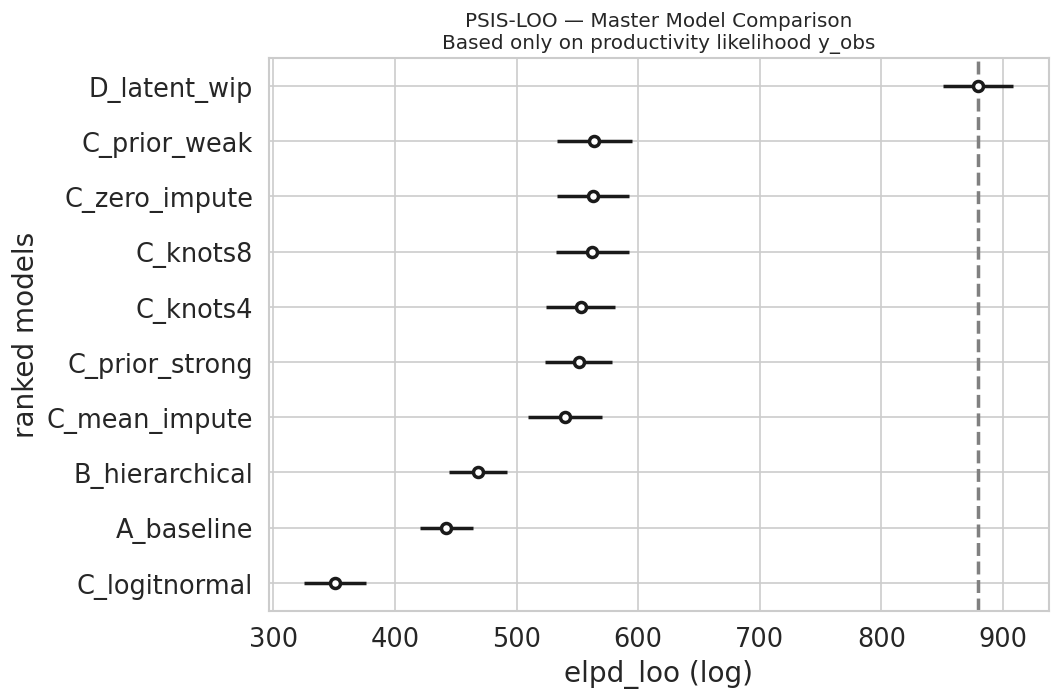


Best model by PSIS-LOO predictive fit: D_latent_wip
Model with highest stacking weight: D_latent_wip
Highest stacking weight: 0.9552


In [26]:
# ── Master PSIS-LOO comparison using productivity likelihood only ─────────────

master_compare_dict = {
    "A_baseline": idata_A,
    "B_hierarchical": idata_B,
    "C_zero_impute": idata_C,
    "C_mean_impute": idata_C_mean,
    "D_latent_wip": idata_D,
    "C_logitnormal": idata_C_logitnormal,
    "C_knots4": idata_C_knots4,
    "C_knots8": idata_C_knots8,
    "C_prior_weak": idata_C_prior_weak,
    "C_prior_strong": idata_C_prior_strong,
}

# Check which likelihood variables are present in each model.
print("Available log-likelihood variables:\n")

for model_name, idata_model in master_compare_dict.items():

    if not hasattr(idata_model, "log_likelihood"):
        raise RuntimeError(
            f"{model_name} has no log_likelihood group."
        )

    likelihood_variables = list(
        idata_model.log_likelihood.data_vars
    )

    print(
        f"{model_name}: {likelihood_variables}"
    )

    if "y_obs" not in likelihood_variables:
        raise KeyError(
            f"{model_name} does not contain "
            "log_likelihood['y_obs']."
        )


# Ensure every model has the same number of productivity observations.
observation_counts = {}

for model_name, idata_model in master_compare_dict.items():

    y_log_likelihood = (
        idata_model.log_likelihood["y_obs"]
    )

    if "obs" not in y_log_likelihood.dims:
        raise ValueError(
            f"{model_name}: y_obs log likelihood "
            "does not contain an 'obs' dimension."
        )

    observation_counts[model_name] = int(
        y_log_likelihood.sizes["obs"]
    )


print("\nNumber of productivity observations:")
print(observation_counts)

if len(set(observation_counts.values())) != 1:
    raise ValueError(
        "The models do not contain the same number of "
        "productivity observations and cannot be directly "
        "compared using PSIS-LOO."
    )


# Important:
# var_name='y_obs' tells ArviZ to ignore Model D's separate
# log_wip_latent_observed likelihood when comparing productivity.
master_comparison = az.compare(
    master_compare_dict,
    ic="loo",
    method="stacking",
    scale="log",
    var_name="y_obs",
)

print(
    "\nMaster PSIS-LOO comparison "
    "(productivity likelihood only):"
)

display(master_comparison)


# ── Plot comparison ───────────────────────────────────────────────────────────

fig, ax = plt.subplots(
    figsize=(9, 6)
)

az.plot_compare(
    master_comparison,
    insample_dev=False,
    ax=ax,
)

ax.set_title(
    "PSIS-LOO — Master Model Comparison\n"
    "Based only on productivity likelihood y_obs"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "02_master_loo_comparison.png",
    dpi=120,
    bbox_inches="tight",
)

plt.show()


# ── Save comparison table ─────────────────────────────────────────────────────

master_comparison.to_csv(
    MODEL_DIR / "02_master_loo_comparison.csv"
)


# The first row is the model with the best estimated predictive fit.
best_elpd_model = master_comparison.index[0]

# The largest weight is the model receiving the highest stacking weight.
best_stacking_model = (
    master_comparison["weight"].idxmax()
)

print(
    "\nBest model by PSIS-LOO predictive fit:",
    best_elpd_model,
)

print(
    "Model with highest stacking weight:",
    best_stacking_model,
)

print(
    "Highest stacking weight:",
    f"{master_comparison.loc[best_stacking_model, 'weight']:.4f}",
)

## 18. Held-Out Test Predictions for Model C (Canonical)

Unchanged from the original notebook — this remains the authoritative Model C
evaluation used by downstream notebooks.


Output()

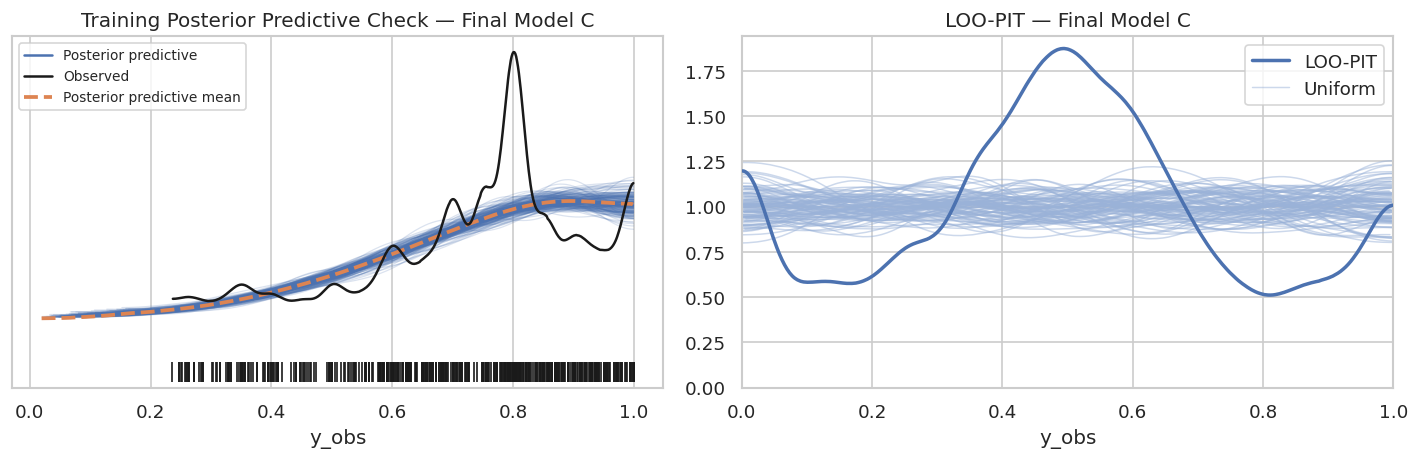

Training posterior-mean draw matrix: (4000, 837)


In [27]:
# ── Training posterior predictive check, then held-out test predictions ───────


def model_c_data_payload(split="fit"):
    if split == "fit":
        X, I, dept, wip_missing, team_idx, inc_positive = (
            X_fit, I_fit, dept_fit, wip_missing_fit, team_idx_fit, incentive_positive_fit
        )
    elif split == "test":
        X, I, dept, wip_missing, team_idx, inc_positive = (
            X_test, I_test, dept_test, wip_missing_test, team_idx_test, incentive_positive_test
        )
    else:
        raise ValueError("split must be 'fit' or 'test'.")

    return {
        "I_spline": I,
        "inc_positive": inc_positive,
        "wip": X[:, COL["wip"]],
        "over_time": X[:, COL["over_time"]],
        "smv": X[:, COL["smv"]],
        "nw": X[:, COL["no_of_workers"]],
        "targeted_productivity": X[:, COL["targeted_productivity"]],
        "style_change": X[:, COL["no_of_style_change"]],
        "sin_dow": X[:, COL["sin_dow"]],
        "cos_dow": X[:, COL["cos_dow"]],
        "dept": dept,
        "wip_miss": wip_missing,
        "team_idx": team_idx,
        "ix_inc_wip": X[:, COL["incentive"]] * X[:, COL["wip"]],
        "ix_wip_nw": X[:, COL["wip"]] * X[:, COL["no_of_workers"]],
    }


def set_model_c_split(split="fit"):
    n_obs = n_fit if split == "fit" else n_test
    pm.set_data(model_c_data_payload(split), coords={"obs": np.arange(n_obs)})


with model_C:
    set_model_c_split("fit")
    ppc_C_train = pm.sample_posterior_predictive(
        idata_C, var_names=["mu_C", "y_obs"], random_seed=RANDOM_SEED,
        return_inferencedata=True, progressbar=True,
    )

idata_C_ppc = idata_C.copy()
idata_C_ppc.add_groups(posterior_predictive=ppc_C_train.posterior_predictive)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
az.plot_ppc(idata_C_ppc, observed_rug=True, ax=axes[0], num_pp_samples=200)
axes[0].set_title("Training Posterior Predictive Check — Final Model C")
az.plot_loo_pit(idata=idata_C_ppc, y="y_obs", ax=axes[1])
axes[1].set_title("LOO-PIT — Final Model C")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_ppc_and_loopit.png", dpi=120)
plt.show()

mu_fit_beta_samples = ppc_C_train.posterior_predictive["mu_C"].stack(sample=("chain", "draw")).transpose("sample", "obs").values
mu_fit_samples = beta_mean_to_productivity(mu_fit_beta_samples)
print(f"Training posterior-mean draw matrix: {mu_fit_samples.shape}")


Output()

Test MAE:        0.0950
Test RMSE:       0.1302
Test R²:         0.4132
80% PI coverage: 0.853
95% PI coverage: 0.956


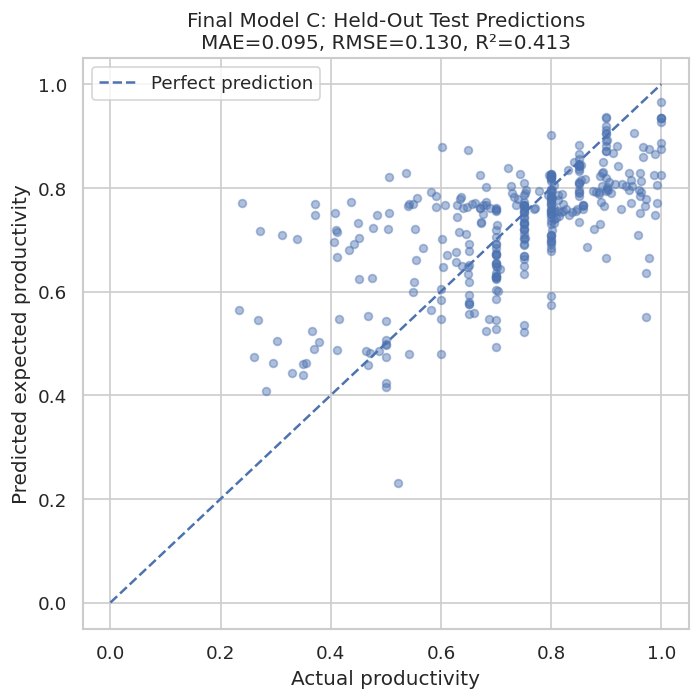


Final predictive comparison across missing-data strategies:
           label  test_mae  test_rmse   test_r2
0  C_mean_impute  0.096220   0.133235  0.385146
1  C_zero_impute  0.095031   0.130158  0.413223
2   D_latent_wip  0.095098   0.133774  0.380161


In [28]:
# ── Held-out test predictions from the same fitted Model C posterior ──────────

with model_C:
    set_model_c_split("test")
    ppc_test = pm.sample_posterior_predictive(
        idata_C, var_names=["mu_C", "y_obs"], predictions=True,
        random_seed=RANDOM_SEED, return_inferencedata=True, progressbar=True,
    )

mu_test_beta_samples = ppc_test.predictions["mu_C"].stack(sample=("chain", "draw")).transpose("sample", "obs").values
y_test_beta_replications = ppc_test.predictions["y_obs"].stack(sample=("chain", "draw")).transpose("sample", "obs").values

mu_test_samples = beta_mean_to_productivity(mu_test_beta_samples)
y_test_replications = beta_mean_to_productivity(y_test_beta_replications)

mu_test_mean = mu_test_samples.mean(axis=0)
mae = mean_absolute_error(y_test_actual, mu_test_mean)
rmse = np.sqrt(mean_squared_error(y_test_actual, mu_test_mean))
r2 = r2_score(y_test_actual, mu_test_mean)

pi80 = np.quantile(y_test_replications, [0.10, 0.90], axis=0)
pi95 = np.quantile(y_test_replications, [0.025, 0.975], axis=0)
coverage80 = np.mean((y_test_actual >= pi80[0]) & (y_test_actual <= pi80[1]))
coverage95 = np.mean((y_test_actual >= pi95[0]) & (y_test_actual <= pi95[1]))

print(f"Test MAE:        {mae:.4f}")
print(f"Test RMSE:       {rmse:.4f}")
print(f"Test R²:         {r2:.4f}")
print(f"80% PI coverage: {coverage80:.3f}")
print(f"95% PI coverage: {coverage95:.3f}")

prediction_table = pd.DataFrame({
    "original_row_index": df_test["original_row_index"].to_numpy(),
    "actual_productivity": y_test_actual,
    "predicted_productivity": mu_test_mean,
    "pi80_lower": pi80[0], "pi80_upper": pi80[1],
    "pi95_lower": pi95[0], "pi95_upper": pi95[1],
    "class3_paper": df_test["class3_paper"].to_numpy(dtype=int),
})
prediction_table.to_csv(MODEL_DIR / "02_model_c_test_predictions.csv", index=False)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_actual, mu_test_mean, alpha=0.45, s=22)
ax.plot([0, 1], [0, 1], "--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual productivity")
ax.set_ylabel("Predicted expected productivity")
ax.set_title(f"Final Model C: Held-Out Test Predictions\nMAE={mae:.3f}, RMSE={rmse:.3f}, R²={r2:.3f}")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_test_predictions.png", dpi=120)
plt.show()

with model_C:
    set_model_c_split("fit")

# Now backfill the master comparison table's C_zero_impute row.
master_test_df.loc[master_test_df["label"] == "C_zero_impute", ["test_mae", "test_rmse", "test_r2"]] = [mae, rmse, r2]
print("\nFinal predictive comparison across missing-data strategies:")
print(master_test_df)
master_test_df.to_csv(MODEL_DIR / "02_missingness_predictive_comparison.csv", index=False)


## 19. Posterior Coefficient Plots for the Final Model C

Available posterior variables in idata_C:
['alpha_team', 'b_cos', 'b_dept', 'b_inc_positive', 'b_inc_wip', 'b_nw', 'b_ot', 'b_sin', 'b_smv', 'b_style', 'b_tp', 'b_wip', 'b_wip_miss', 'b_wip_nw', 'mu_C', 'mu_team', 'nu', 'sigma_team', 'spline_effect', 'w_spline', 'z_team']


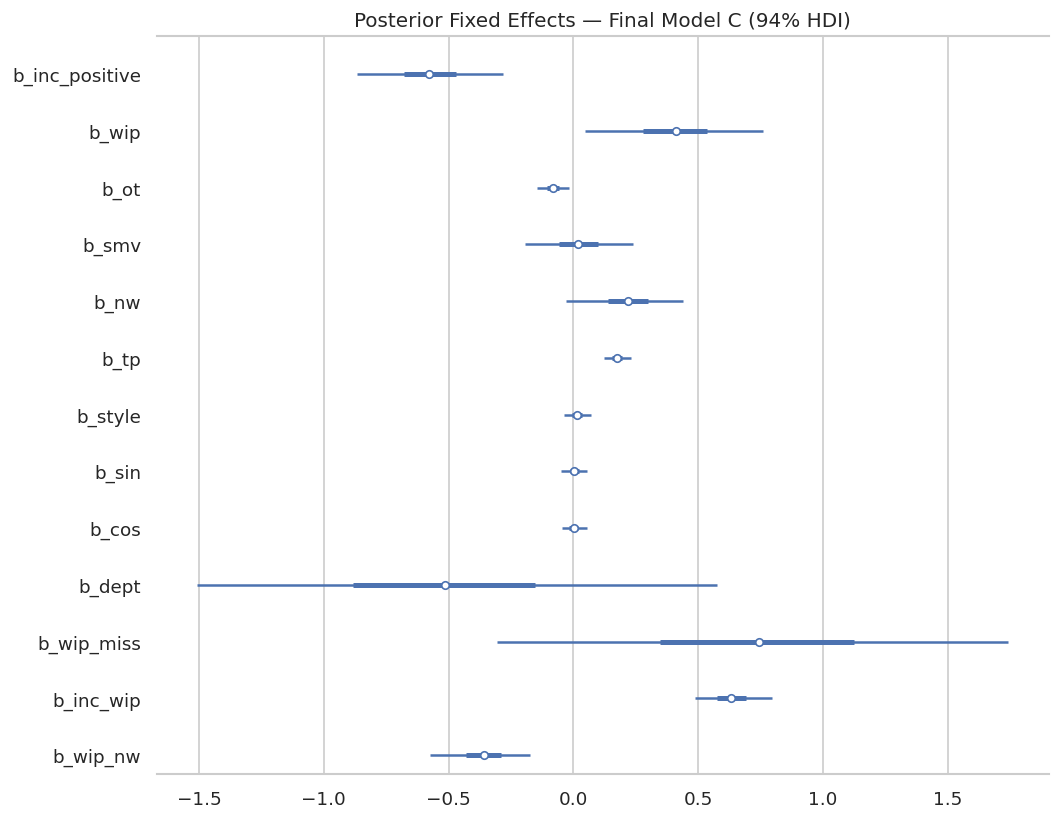

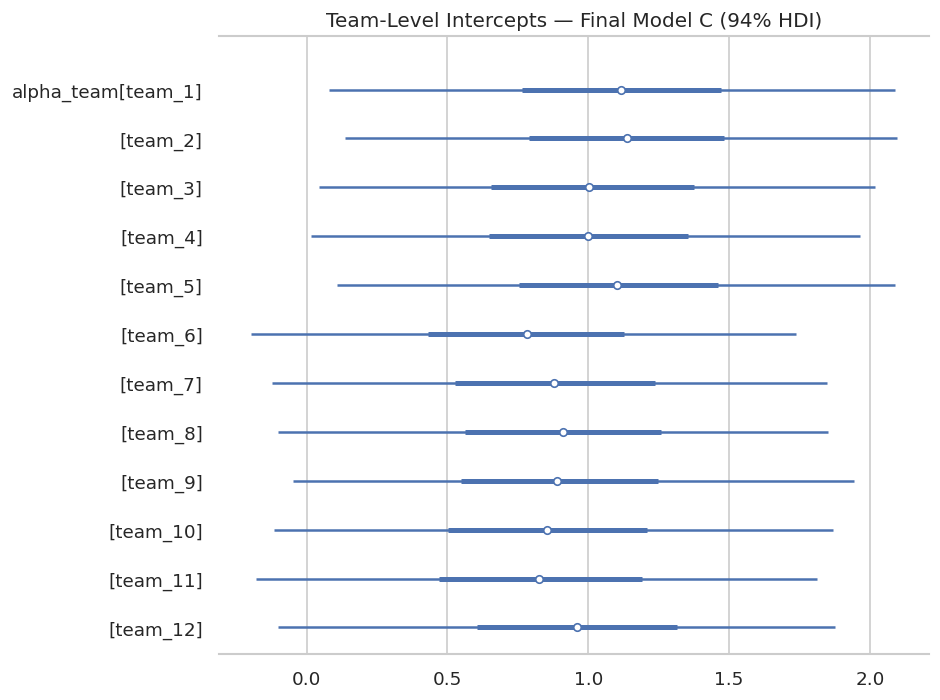

In [29]:
print("Available posterior variables in idata_C:")
print(list(idata_C.posterior.data_vars))

fixed_effects = [
    "b_inc_positive", "b_wip", "b_ot", "b_smv", "b_nw", "b_tp", "b_style",
    "b_sin", "b_cos", "b_dept", "b_wip_miss", "b_inc_wip", "b_wip_nw",
]
available_effects = [v for v in fixed_effects if v in idata_C.posterior.data_vars]

az.plot_forest(idata_C, var_names=available_effects, combined=True, hdi_prob=0.94, figsize=(9, 7))
plt.title("Posterior Fixed Effects — Final Model C (94% HDI)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_posterior_effects.png", dpi=120)
plt.show()

az.plot_forest(idata_C, var_names=["alpha_team"], combined=True, hdi_prob=0.94, figsize=(8, 6))
plt.title("Team-Level Intercepts — Final Model C (94% HDI)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_team_intercepts.png", dpi=120)
plt.show()


## 20. Save Authoritative Artifacts and Push to GitHub

Saves the canonical Model C posterior (unchanged file names, for downstream
compatibility) plus the new Model D posterior and every sensitivity-analysis
CSV/plot, then pushes everything back to the same repository the same way
the original notebook did.


In [30]:
# ── Save posteriors and reproducibility artifacts ──────────────────────────────

import hashlib
import json

BAYES_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

model_a_path = BAYES_DIR / "02_model_A_baseline.nc"
model_b_path = BAYES_DIR / "02_model_B_hierarchical.nc"
model_c_path = BAYES_DIR / "02_model_C_final_logwip_monotone.nc"
model_d_path = BAYES_DIR / "02_model_D_latent_wip.nc"
model_c_mean_path = BAYES_DIR / "02_model_C_mean_impute.nc"
model_c_logitnormal_path = BAYES_DIR / "02_model_C_logitnormal.nc"

idata_A.to_netcdf(str(model_a_path))
idata_B.to_netcdf(str(model_b_path))
idata_C.to_netcdf(str(model_c_path))
idata_D.to_netcdf(str(model_d_path))
idata_C_mean.to_netcdf(str(model_c_mean_path))
idata_C_logitnormal.to_netcdf(str(model_c_logitnormal_path))

master_comparison.to_csv(MODEL_DIR / "02_loo_comparison.csv")  # kept for backward compatibility

posterior_prediction_path = MODEL_DIR / "02_model_C_posterior_predictions.npz"
np.savez_compressed(
    posterior_prediction_path,
    mu_fit_samples=mu_fit_samples.astype(np.float32),
    mu_test_samples=mu_test_samples.astype(np.float32),
    y_fit_actual=y_fit_actual.astype(np.float32),
    y_test_actual=y_test_actual.astype(np.float32),
    fit_indices=np.asarray(fit_indices, dtype=np.int64),
    test_indices=np.asarray(test_indices, dtype=np.int64),
)

with open(DATA_PATH, "rb") as file_handle:
    dataset_sha256 = hashlib.sha256(file_handle.read()).hexdigest()

artifact_metadata = {
    "model_name": "Model_C_final_logwip_monotone",
    "posterior_file": str(model_c_path.relative_to(REPO_DIR)),
    "prediction_file": str(posterior_prediction_path.relative_to(REPO_DIR)),
    "dataset_file": str(DATA_PATH.relative_to(REPO_DIR)),
    "dataset_sha256": dataset_sha256,
    "random_seed": int(RANDOM_SEED),
    "test_size": float(TEST_SIZE),
    "n_total": int(len(df_full)),
    "n_fit": int(n_fit),
    "n_test": int(n_test),
    "wip_strategy": "log_wip_imputed + wip_missing_flag (zero-impute; see Model D for latent alternative)",
    "target": "productivity_beta_smithson_verkuilen (verified, computed in this notebook)",
    "feature_columns": list(feat_cols),
    "scaler_mean": scaler2.mean_.tolist(),
    "scaler_scale": scaler2.scale_.tolist(),
    "spline_degree": int(SPLINE_DEGREE),
    "spline_knots_standardized_log_incentive": knots_inc.tolist(),
    "spline_lower": float(spline_lower),
    "spline_upper": float(spline_upper),
    "n_spline_terms": int(n_spline),
    "team_labels": [item.item() if hasattr(item, "item") else item for item in team_labels],
    "formula": (
        "team intercept + positive-incentive indicator + monotone incentive "
        "spline + log WIP + log overtime + log SMV + log workers + targeted "
        "productivity + style changes + weekday sine/cosine + department + "
        "WIP-missing indicator + incentive×WIP + WIP×workers"
    ),
    "sampling": {
        "draws": 1000, "tune": 1500, "chains": 4, "target_accept": 0.95,
        "divergences": int(divergences), "max_rhat": float(max_rhat),
        "min_ess_bulk": float(min_ess_bulk),
    },
    "test_metrics": {
        "mae": float(mae), "rmse": float(rmse), "r2": float(r2),
        "coverage80": float(coverage80), "coverage95": float(coverage95),
    },
    "alternative_models": {
        "D_latent_wip": {
            "posterior_file": str(model_d_path.relative_to(REPO_DIR)),
            "test_metrics": {"mae": float(mae_D), "rmse": float(rmse_D), "r2": float(r2_D)},
            "divergences": int(divergences_D), "max_rhat": float(max_rhat_D),
        },
        "C_mean_impute": {"posterior_file": str(model_c_mean_path.relative_to(REPO_DIR))},
        "C_logitnormal": {"posterior_file": str(model_c_logitnormal_path.relative_to(REPO_DIR))},
    },
    "best_model_by_loo": str(master_comparison.index[0]),
}

metadata_path = MODEL_DIR / "02_model_C_artifact_metadata.json"
with open(metadata_path, "w", encoding="utf-8") as file_handle:
    json.dump(artifact_metadata, file_handle, indent=2)

print("Authoritative posterior saved:", model_c_path)
print("Latent-WIP posterior saved:", model_d_path)
print("Reproducibility metadata saved:", metadata_path)
print("\nKey findings:")
print(f"  Best model by PSIS-LOO: {master_comparison.index[0]}")
print(f"  Model C test RMSE: {rmse:.4f}")
print(f"  Model D test RMSE: {rmse_D:.4f}")


Authoritative posterior saved: /content/ProdFusion/bayesian/02_model_C_final_logwip_monotone.nc
Latent-WIP posterior saved: /content/ProdFusion/bayesian/02_model_D_latent_wip.nc
Reproducibility metadata saved: /content/ProdFusion/models/02_model_C_artifact_metadata.json

Key findings:
  Best model by PSIS-LOO: D_latent_wip
  Model C test RMSE: 0.1302
  Model D test RMSE: 0.1338


In [32]:
# ── Repair failed push by storing Bayesian .nc files with Git LFS ─────────────

from pathlib import Path
from getpass import getpass
from urllib.parse import quote
import subprocess
import os

REPO_DIR = Path("/content/ProdFusion")
os.chdir(REPO_DIR)

# ── 1. Install and initialize Git LFS ─────────────────────────────────────────

subprocess.run(
    ["apt-get", "update", "-qq"],
    check=True,
)

subprocess.run(
    ["apt-get", "install", "-y", "git-lfs"],
    check=True,
)

subprocess.run(
    ["git", "lfs", "install"],
    check=True,
)

# ── 2. Undo only the latest local commit ──────────────────────────────────────
# The files remain safely in the working directory.

subprocess.run(
    ["git", "reset", "--soft", "HEAD~1"],
    check=True,
)

# Unstage everything before applying the LFS rules.
subprocess.run(
    ["git", "reset"],
    check=True,
)

# ── 3. Track all Bayesian NetCDF files with Git LFS ───────────────────────────

subprocess.run(
    ["git", "lfs", "track", "bayesian/*.nc"],
    check=True,
)

# .gitattributes contains the LFS tracking rule.
subprocess.run(
    ["git", "add", ".gitattributes"],
    check=True,
)

# ── 4. Stage all required Bayesian outputs again ──────────────────────────────

files_to_push = [
    "bayesian/",
    "output/",
    "models/02_loo_comparison.csv",
    "models/02_missingness_loo_comparison.csv",
    "models/02_missingness_predictive_comparison.csv",
    "models/02_likelihood_loo_comparison.csv",
    "models/02_knots_loo_comparison.csv",
    "models/02_prior_strength_loo_comparison.csv",
    "models/02_master_loo_comparison.csv",
    "models/02_model_C_artifact_metadata.json",
    "models/02_model_C_posterior_predictions.npz",
    "models/02_model_c_test_predictions.csv",
]

manual_prior_file = (
    REPO_DIR
    / "models/02_prior_sensitivity_manual.csv"
)

if manual_prior_file.exists():
    files_to_push.append(
        "models/02_prior_sensitivity_manual.csv"
    )

subprocess.run(
    ["git", "add", "-f", *files_to_push],
    check=True,
)

# ── 5. Confirm that .nc files are now handled by LFS ──────────────────────────

print("\nFiles tracked by Git LFS:\n")

lfs_result = subprocess.run(
    ["git", "lfs", "ls-files"],
    capture_output=True,
    text=True,
    check=True,
)

print(lfs_result.stdout)

if "02_model_D_latent_wip.nc" not in lfs_result.stdout:
    raise RuntimeError(
        "The latent-WIP model is not being tracked by Git LFS."
    )

print("\nGit status:\n")

status_result = subprocess.run(
    ["git", "status", "--short"],
    capture_output=True,
    text=True,
    check=True,
)

print(status_result.stdout)

# ── 6. Create the corrected commit ────────────────────────────────────────────

commit_result = subprocess.run(
    [
        "git",
        "commit",
        "-m",
        "Add v2 Bayesian models with NetCDF artifacts in Git LFS",
    ],
    capture_output=True,
    text=True,
)

print("\nCommit result:\n")
print(commit_result.stdout)

if commit_result.stderr:
    print(commit_result.stderr)

if commit_result.returncode != 0:
    raise RuntimeError(
        "The corrected Git commit failed."
    )

# ── 7. Authenticate securely ──────────────────────────────────────────────────

token = getpass(
    "Paste your GitHub personal access token: "
).strip()

if not token:
    raise ValueError(
        "GitHub token was not provided."
    )

safe_token = quote(
    token,
    safe="",
)

repo_url = (
    f"https://dakshini01:{safe_token}"
    "@github.com/dakshini01/ProdFusion.git"
)

branch = subprocess.run(
    ["git", "branch", "--show-current"],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip() or "main"

# ── 8. Pull and push the corrected commit ─────────────────────────────────────

pull_result = subprocess.run(
    [
        "git",
        "pull",
        "--rebase",
        repo_url,
        branch,
    ],
    capture_output=True,
    text=True,
)

print("\nPull result:", pull_result.returncode)
print(pull_result.stdout)

if pull_result.returncode != 0:
    print(
        pull_result.stderr.replace(
            token,
            "***",
        )
    )

    raise RuntimeError(
        "Git pull failed."
    )

push_result = subprocess.run(
    [
        "git",
        "push",
        repo_url,
        branch,
    ],
    capture_output=True,
    text=True,
)

print("\nPush result:", push_result.returncode)
print(push_result.stdout)

if push_result.returncode != 0:
    print(
        push_result.stderr.replace(
            token,
            "***",
        )
    )

    raise RuntimeError(
        "Git LFS push failed."
    )

print(
    "\n✓ Bayesian models, tables and figures were "
    "successfully pushed using Git LFS."
)


Files tracked by Git LFS:

edce209414 * bayesian/02_model_A_baseline.nc
4c97694046 * bayesian/02_model_B_hierarchical.nc
19415ce2cf * bayesian/02_model_C_final_logwip_monotone.nc
27a62d90e1 * bayesian/02_model_C_logitnormal.nc
7342cd93c6 * bayesian/02_model_C_mean_impute.nc
12113fb787 * bayesian/02_model_D_latent_wip.nc
549101e12b * bayesian/model_A_baseline.nc
e60edfcbd7 * bayesian/model_B_hierarchical.nc
8cc7563ff7 * bayesian/model_C_full.nc


Git status:

A  .gitattributes
M  bayesian/02_model_A_baseline.nc
M  bayesian/02_model_B_hierarchical.nc
M  bayesian/02_model_C_final_logwip_monotone.nc
A  bayesian/02_model_C_logitnormal.nc
A  bayesian/02_model_C_mean_impute.nc
A  bayesian/02_model_D_latent_wip.nc
M  bayesian/model_A_baseline.nc
M  bayesian/model_B_hierarchical.nc
M  bayesian/model_C_full.nc
A  models/02_knots_loo_comparison.csv
A  models/02_likelihood_loo_comparison.csv
M  models/02_loo_comparison.csv
A  models/02_master_loo_comparison.csv
A  models/02_missingness_loo_compar

## 21. Summary

**Target:** the Beta-likelihood response is now the verified Smithson–Verkuilen
transform, computed explicitly in Section 5 — not a hard clip, and not
dependent on an upstream column that might silently be something else.

**Missing WIP:** three strategies were compared head-to-head — zero-impute
(Model C), mean-impute (Model C_mean), and a latent-variable joint model
(Model D) that estimates each missing value jointly with the productivity
regression and propagates that uncertainty into every downstream coefficient
and prediction. Section 15/17 report whether conclusions are robust across
these assumptions.

**PSIS-LOO sweep:** Beta vs. Jacobian-corrected Logit-Normal likelihood,
4/6/8-knot incentive splines, and 0.5×/1×/2× prior strength were each
compared via PSIS-LOO. A formal power-scaling prior-sensitivity diagnostic
(via `priorsense`, or a manual importance-sampling fallback) was also run on
the final Model C without any refits.

The single master comparison table in Section 17 ranks every model fit in
this notebook by PSIS-LOO. Model C remains the saved "authoritative" posterior
for downstream notebooks (for naming compatibility), but `artifact_metadata`
records which model actually won by LOO, and the Model D posterior is saved
alongside it so downstream work can switch if desired.
